## Phase 0 — Config & Campaign Intelligence Setup

In [2]:
# [NOTE] config/config.py
import os, warnings
warnings.filterwarnings('ignore')

CONFIG = {
    'RAW_CSV':        r'data/raw/influencer_campaigns.csv',
    'PROCESSED_CSV':  'data/processed/campaigns_clean.csv',
    'FEAT_CSV':       'data/processed/campaigns_features.csv',
    'REPORTS_DIR':    'reports/',
    'MODELS_DIR':     'models/',
    'COL_ID':              'Influencer_ID',
    'COL_PLATFORM':        'Platform',
    'COL_NICHE':           'Audience_Niche',
    'COL_FOLLOWERS':       'Follower_Count',
    'COL_ENGAGEMENT':      'Engagement_Rate_Pct',
    'COL_COMMENTS':        'Avg_Comments_Per_Post',
    'COL_COLLABS':         'Past_Brand_Collaborations',
    'COL_COST':            'Campaign_Cost_USD',
    'COL_DISCOUNT_USES':   'Discount_Code_Uses',
    'COL_REVENUE':         'Revenue_Generated_USD',
    'COL_TARGET':          'High_ROI_Campaign',
    'RANDOM_STATE':        42,
    'TEST_SIZE':           0.2,
    'ANOMALY_CONT':        0.08,
    'ROI_HIGH_THRESHOLD':  3.0,
    'ROI_MEDIUM_THRESHOLD':1.5,
    'ENGAGEMENT_HIGH':     5.0,
    'ENGAGEMENT_MEDIUM':   2.0,
    'FOLLOWER_MICRO':      50000,
    'FOLLOWER_MACRO':      500000,
    'CONVERSION_RATE_GOOD':0.005,
    'COST_PER_USE_THRESHOLD':50.0,
    'REV_PER_FOLLOWER_GOOD':0.01,
    'COLLAB_EXPERIENCED':  5,
    'TARGET_MAP':    {'Yes': 1, 'No': 0},
    'TARGET_LABELS': {1: 'High ROI', 0: 'Low ROI'},
    'BIGQUERY': {
        'project_id': '',
        'dataset':    '',
        'table':      'feat',
        'credentials_file': 'credentials.json',
    },
}

for d in [CONFIG['REPORTS_DIR'], CONFIG['MODELS_DIR'],
          'data/raw', 'data/processed', 'reports/frontend']:
    os.makedirs(d, exist_ok=True)

print("CONFIG loaded. Directories created.")
print("Thresholds => ROI_HIGH:", CONFIG['ROI_HIGH_THRESHOLD'],
      "| ENGAGEMENT_HIGH:", CONFIG['ENGAGEMENT_HIGH'],
      "| ANOMALY_CONT:", CONFIG['ANOMALY_CONT'])


CONFIG loaded. Directories created.
Thresholds => ROI_HIGH: 3.0 | ENGAGEMENT_HIGH: 5.0 | ANOMALY_CONT: 0.08


## Phase 1 — Data Ingestion & Campaign Portfolio Validation

In [3]:
# [NOTE] src/data/ingest.py
import pandas as pd
import numpy as np

df = pd.read_csv(CONFIG['RAW_CSV'])
print("Raw shape:", df.shape)

EXPECTED_COLS = [
    CONFIG['COL_ID'], CONFIG['COL_PLATFORM'], CONFIG['COL_NICHE'],
    CONFIG['COL_FOLLOWERS'], CONFIG['COL_ENGAGEMENT'], CONFIG['COL_COMMENTS'],
    CONFIG['COL_COLLABS'], CONFIG['COL_COST'], CONFIG['COL_DISCOUNT_USES'],
    CONFIG['COL_REVENUE'], CONFIG['COL_TARGET']
]
missing_cols = [c for c in EXPECTED_COLS if c not in df.columns]
schema_ok = len(missing_cols) == 0
print("Schema OK:", schema_ok)
if missing_cols:
    print("MISSING COLUMNS:", missing_cols)

null_report = df.isnull().sum()
null_report = null_report[null_report > 0]
print("\nNull report (only columns with nulls):")
print(null_report if len(null_report) > 0 else "  No nulls found.")

print("\nDtype report:")
print(df.dtypes)

print("\nTarget distribution (", CONFIG['COL_TARGET'], "):")
tc = df[CONFIG['COL_TARGET']].value_counts()
tcp = df[CONFIG['COL_TARGET']].value_counts(normalize=True) * 100
for k in tc.index:
    print(f"  {k}: {tc[k]}  ({tcp[k]:.1f}%)")

print("\nPlatform distribution:")
print(df[CONFIG['COL_PLATFORM']].value_counts())

print("\nNiche distribution:")
print(df[CONFIG['COL_NICHE']].value_counts())

print("\nFollower range:")
print(f"  Min: {df[CONFIG['COL_FOLLOWERS']].min():,}")
print(f"  Max: {df[CONFIG['COL_FOLLOWERS']].max():,}")
print(f"  Median: {df[CONFIG['COL_FOLLOWERS']].median():,.0f}")

validation = {
    'rows': len(df),
    'cols': len(df.columns),
    'nulls': int(df.isnull().sum().sum()),
    'target_balance_pct_high': round(tcp.get('Yes', 0.0), 2),
    'schema_ok': schema_ok,
}
print("\nValidation summary:", validation)


Raw shape: (208, 11)
Schema OK: True

Null report (only columns with nulls):
  No nulls found.

Dtype report:
Influencer_ID                 object
Platform                      object
Audience_Niche                object
Follower_Count                 int64
Engagement_Rate_Pct          float64
Avg_Comments_Per_Post          int64
Past_Brand_Collaborations      int64
Campaign_Cost_USD            float64
Discount_Code_Uses             int64
Revenue_Generated_USD        float64
High_ROI_Campaign             object
dtype: object

Target distribution ( High_ROI_Campaign ):
  Yes: 200  (96.2%)
  No: 8  (3.8%)

Platform distribution:
Platform
TikTok       100
Instagram     76
YouTube       32
Name: count, dtype: int64

Niche distribution:
Audience_Niche
Fashion     77
Skincare    66
Fitness     42
Tech        23
Name: count, dtype: int64

Follower range:
  Min: 11,015
  Max: 249,564
  Median: 123,440

Validation summary: {'rows': 208, 'cols': 11, 'nulls': 0, 'target_balance_pct_high': np.floa

## Phase 2 — Data Cleaning & Campaign Standardisation

In [4]:
# [NOTE] src/data/clean.py
if 'df' not in dir():
    df = pd.read_csv(CONFIG['RAW_CSV'])

df_clean = df.copy()

# dtype enforcement
for col in [CONFIG['COL_FOLLOWERS'], CONFIG['COL_COMMENTS'],
            CONFIG['COL_COLLABS'], CONFIG['COL_DISCOUNT_USES']]:
    df_clean[col] = df_clean[col].astype('int64')

for col in [CONFIG['COL_ENGAGEMENT'], CONFIG['COL_COST'], CONFIG['COL_REVENUE']]:
    df_clean[col] = df_clean[col].astype('float64')

# IQR outlier capping
def iqr_cap(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return series.clip(lo, hi), lo, hi

for col in [CONFIG['COL_FOLLOWERS'], CONFIG['COL_COST'], CONFIG['COL_REVENUE'],
            CONFIG['COL_ENGAGEMENT'], CONFIG['COL_COMMENTS']]:
    before_min = df_clean[col].min()
    before_max = df_clean[col].max()
    df_clean[col], lo, hi = iqr_cap(df_clean[col])
    print(f"IQR cap [{col}]: range [{before_min:.1f}, {before_max:.1f}] -> [{lo:.1f}, {hi:.1f}]")

# deduplication
before_dedup = len(df_clean)
df_clean = df_clean.drop_duplicates(
    subset=[CONFIG['COL_ID'], CONFIG['COL_COST']]
).reset_index(drop=True)
print(f"\nDedup: removed {before_dedup - len(df_clean)} rows. Remaining: {len(df_clean)}")

# label columns
df_clean['target_numeric'] = df_clean[CONFIG['COL_TARGET']].map(CONFIG['TARGET_MAP'])
df_clean['target_label']   = df_clean['target_numeric'].map(CONFIG['TARGET_LABELS'])

def follower_tier(n):
    if n < CONFIG['FOLLOWER_MICRO']:  return 'Micro'
    if n < CONFIG['FOLLOWER_MACRO']:  return 'Macro'
    return 'Mega'

df_clean['follower_tier'] = df_clean[CONFIG['COL_FOLLOWERS']].apply(follower_tier)
df_clean[CONFIG['COL_PLATFORM']] = df_clean[CONFIG['COL_PLATFORM']].str.strip().str.title()

df_clean.to_csv(CONFIG['PROCESSED_CSV'], index=False, encoding='utf-8')
print(f"Saved cleaned data -> {CONFIG['PROCESSED_CSV']}")
print("Clean shape:", df_clean.shape)
print("\nFollower tier distribution:")
print(df_clean['follower_tier'].value_counts())


IQR cap [Follower_Count]: range [11015.0, 249564.0] -> [-126957.9, 373181.1]
IQR cap [Campaign_Cost_USD]: range [233.1, 3879.1] -> [-1635.9, 4831.3]
IQR cap [Revenue_Generated_USD]: range [1222.0, 59306.8] -> [-11248.7, 34524.9]
IQR cap [Engagement_Rate_Pct]: range [0.5, 13.3] -> [-1.0, 14.7]
IQR cap [Avg_Comments_Per_Post]: range [48.0, 2224.0] -> [-468.9, 1796.1]

Dedup: removed 0 rows. Remaining: 208
Saved cleaned data -> data/processed/campaigns_clean.csv
Clean shape: (208, 14)

Follower tier distribution:
follower_tier
Macro    161
Micro     47
Name: count, dtype: int64


## Phase 3 — Feature Engineering: Campaign Performance Intelligence

In [5]:
# [NOTE] src/features/engineer.py
import numpy as np
if 'df_clean' not in dir():
    df_clean = pd.read_csv(CONFIG['PROCESSED_CSV'])

df_feat = df_clean.copy()

# 1. ROI Ratio — the fundamental campaign efficiency metric
df_feat['roi_ratio'] = (
    df_feat[CONFIG['COL_REVENUE']] /
    df_feat[CONFIG['COL_COST']].replace(0, 1)
)

# 2. Cost Per Discount Use — cost to acquire one tracked conversion
df_feat['cost_per_discount_use'] = (
    df_feat[CONFIG['COL_COST']] /
    df_feat[CONFIG['COL_DISCOUNT_USES']].replace(0, 1)
)

# 3. Revenue Per Follower — audience yield, cuts through vanity metrics
df_feat['revenue_per_follower'] = (
    df_feat[CONFIG['COL_REVENUE']] /
    df_feat[CONFIG['COL_FOLLOWERS']].replace(0, 1)
)

# 4. Conversion Rate — influencer's actual persuasion power
df_feat['conversion_rate'] = (
    df_feat[CONFIG['COL_DISCOUNT_USES']] /
    df_feat[CONFIG['COL_FOLLOWERS']].replace(0, 1)
)

# 5. Engagement-to-Cost Efficiency — paying efficiently for engagement AND conversions
df_feat['engagement_to_cost_efficiency'] = (
    df_feat[CONFIG['COL_ENGAGEMENT']] * df_feat[CONFIG['COL_DISCOUNT_USES']] /
    df_feat[CONFIG['COL_COST']].replace(0, 1)
)

# 6. Audience Quality Score — composite 0-1 index normalised across platforms
def minmax_norm(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn + 1e-9)

df_feat['comments_per_follower'] = (
    df_feat[CONFIG['COL_COMMENTS']] /
    df_feat[CONFIG['COL_FOLLOWERS']].replace(0, 1)
)
df_feat['audience_quality_score'] = (
    0.4 * minmax_norm(df_feat[CONFIG['COL_ENGAGEMENT']]) +
    0.3 * minmax_norm(df_feat['conversion_rate']) +
    0.3 * minmax_norm(df_feat['comments_per_follower'])
)

# 7. Influencer Experience Score — log-scaled collaboration count
df_feat['influencer_experience_score'] = np.log1p(df_feat[CONFIG['COL_COLLABS']])

# 8. Revenue Per Comment — measures comment-to-revenue intent
df_feat['revenue_per_comment'] = (
    df_feat[CONFIG['COL_REVENUE']] /
    df_feat[CONFIG['COL_COMMENTS']].replace(0, 1)
)

# 9. Cost Efficiency Tier — categorical label for dashboard filtering
df_feat['cost_efficiency_tier'] = pd.cut(
    df_feat['cost_per_discount_use'],
    bins=[0, 25, 50, 100, float('inf')],
    labels=['Elite', 'Good', 'Fair', 'Poor']
)

# 10. Follower Tier (if not already set)
if 'follower_tier' not in df_feat.columns:
    df_feat['follower_tier'] = df_feat[CONFIG['COL_FOLLOWERS']].apply(
        lambda n: 'Micro' if n < CONFIG['FOLLOWER_MICRO']
                  else ('Macro' if n < CONFIG['FOLLOWER_MACRO'] else 'Mega')
    )

# 11. Engagement Tier — business label replacing raw percentage
def eng_tier(x):
    if x >= CONFIG['ENGAGEMENT_HIGH']:   return 'Elite'
    if x >= CONFIG['ENGAGEMENT_MEDIUM']: return 'Healthy'
    return 'Low'

df_feat['engagement_tier'] = df_feat[CONFIG['COL_ENGAGEMENT']].apply(eng_tier)

# 12. Platform-Niche Combo — interaction feature for combined channel x vertical signal
df_feat['platform_niche_combo'] = (
    df_feat[CONFIG['COL_PLATFORM']].astype(str) + '_' +
    df_feat[CONFIG['COL_NICHE']].astype(str)
)

df_feat.to_csv(CONFIG['FEAT_CSV'], index=False, encoding='utf-8')
print("Feature engineering complete.")
new_feats = ['roi_ratio','cost_per_discount_use','revenue_per_follower','conversion_rate',
             'engagement_to_cost_efficiency','audience_quality_score','influencer_experience_score',
             'revenue_per_comment','cost_efficiency_tier','follower_tier','engagement_tier',
             'platform_niche_combo']
print("New features created:", new_feats)
print("Feature matrix shape:", df_feat.shape)
print("\nROI Ratio stats:")
print(df_feat['roi_ratio'].describe().round(3))


Feature engineering complete.
New features created: ['roi_ratio', 'cost_per_discount_use', 'revenue_per_follower', 'conversion_rate', 'engagement_to_cost_efficiency', 'audience_quality_score', 'influencer_experience_score', 'revenue_per_comment', 'cost_efficiency_tier', 'follower_tier', 'engagement_tier', 'platform_niche_combo']
Feature matrix shape: (208, 26)

ROI Ratio stats:
count    208.000
mean       8.426
std        5.137
min        0.703
25%        4.527
50%        7.472
75%       11.365
max       27.544
Name: roi_ratio, dtype: float64


## Phase 4 — Exploratory Data Analysis: Campaign Intelligence Visualisations

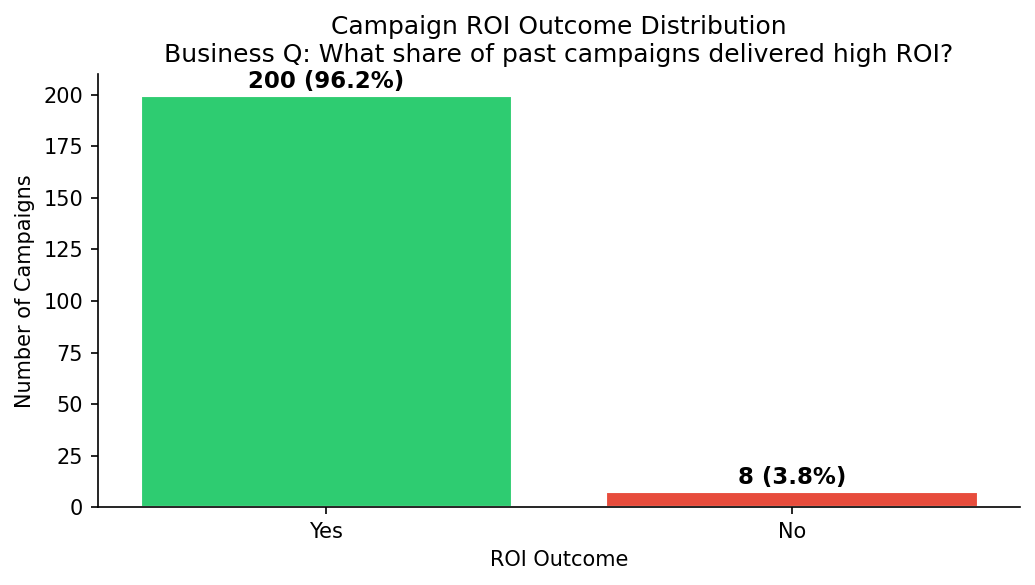

Chart 1 saved.


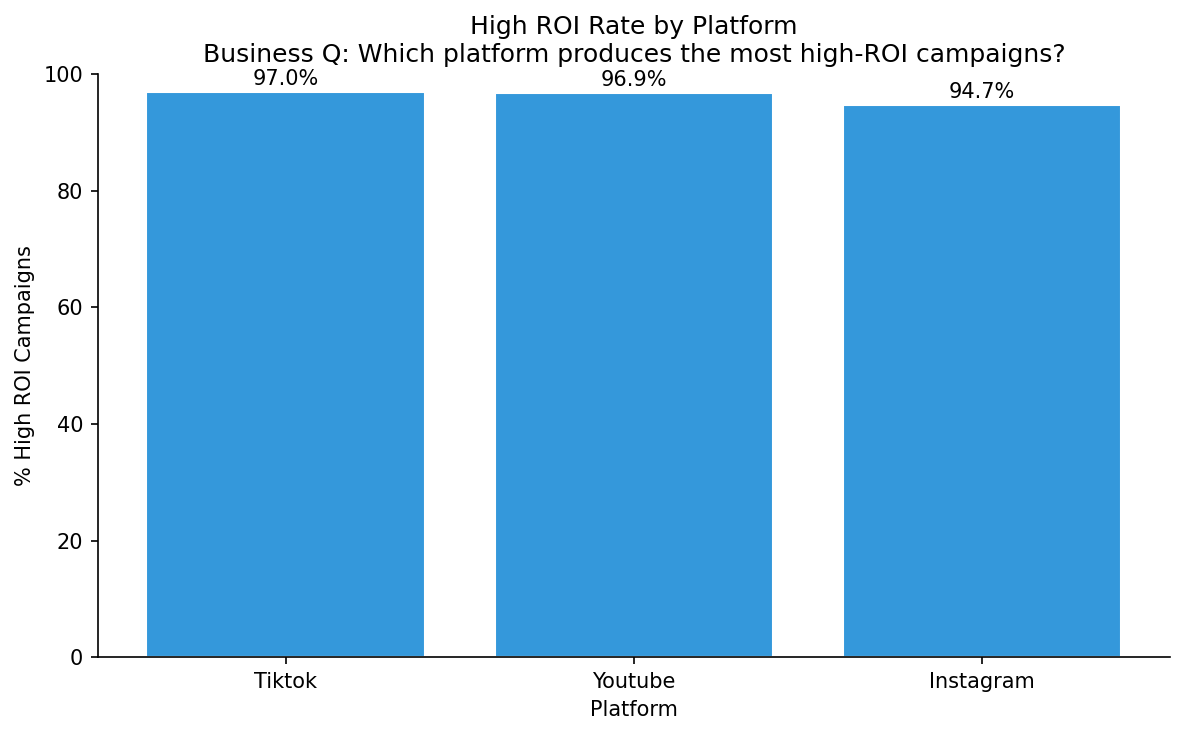

Chart 2 saved.


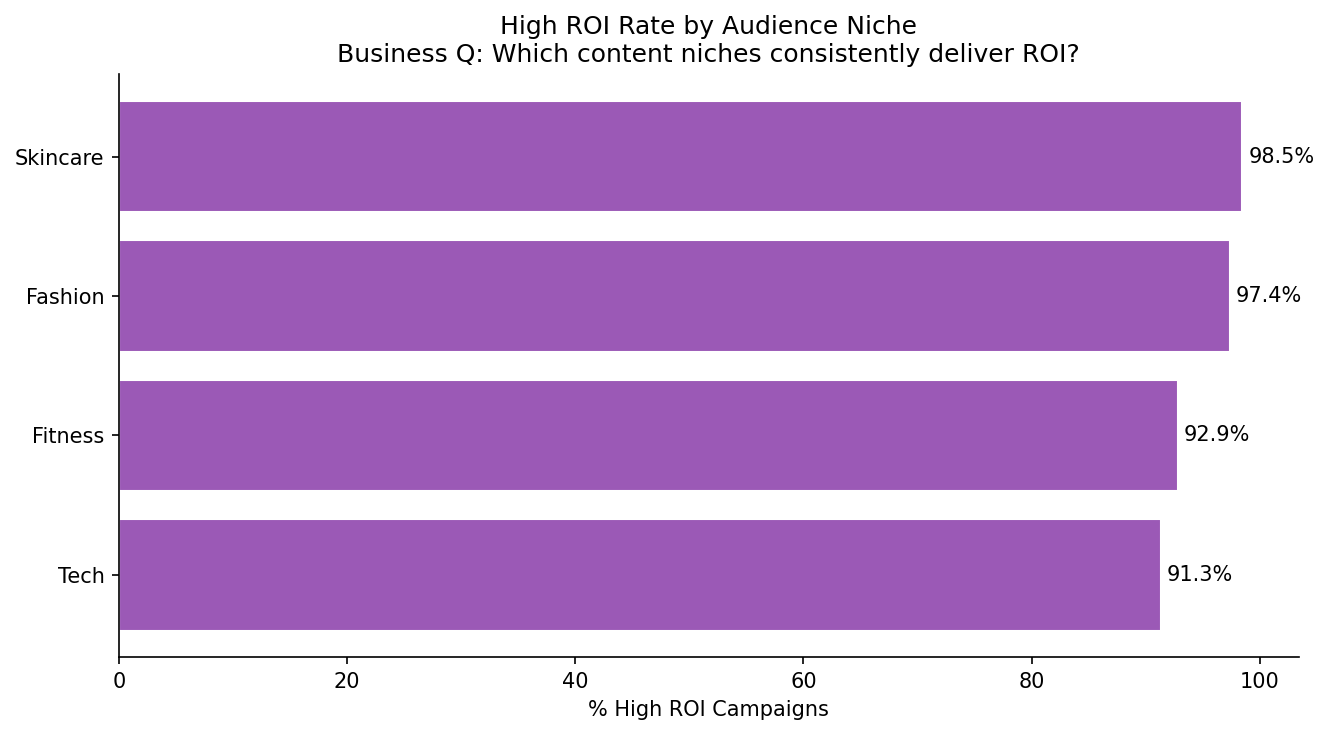

Chart 3 saved.


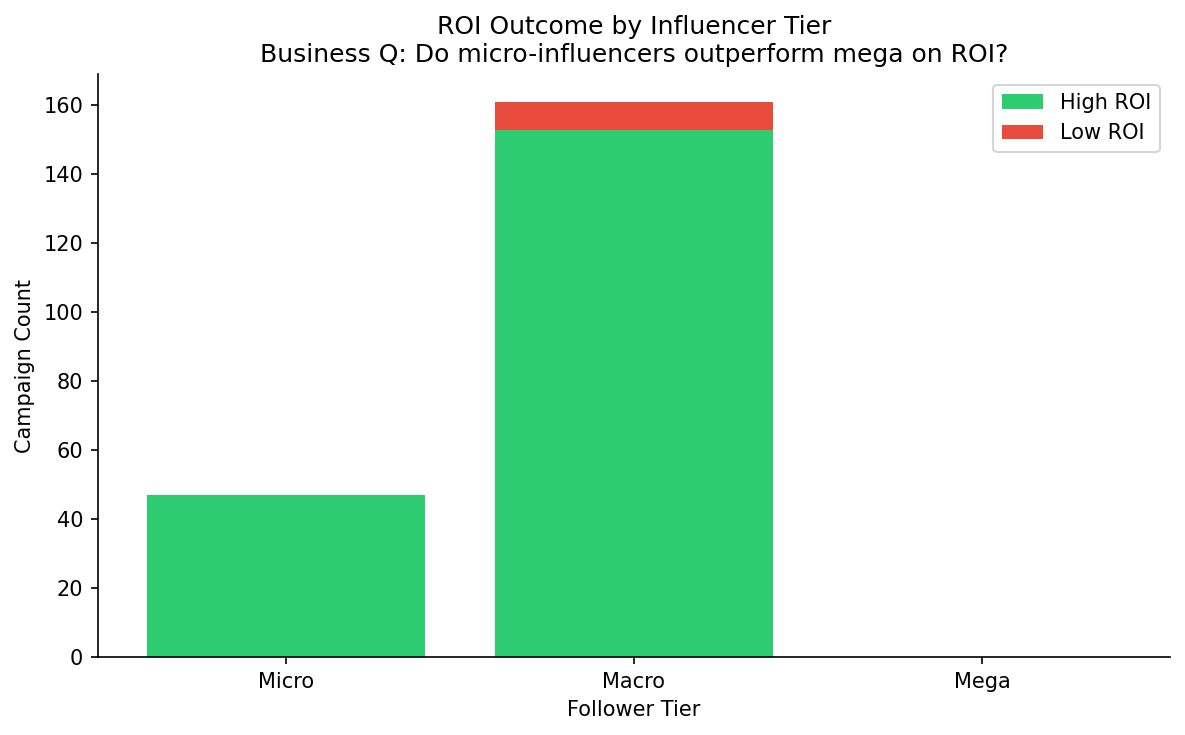

Chart 4 saved.


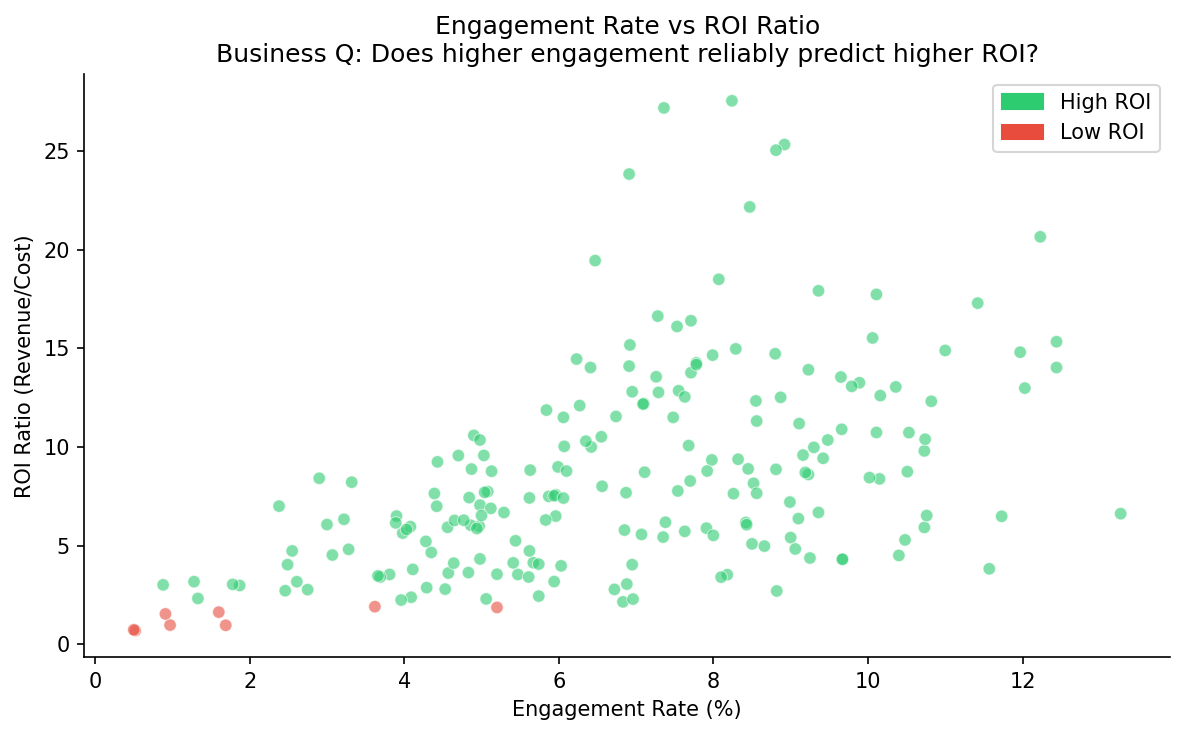

Chart 5 saved.


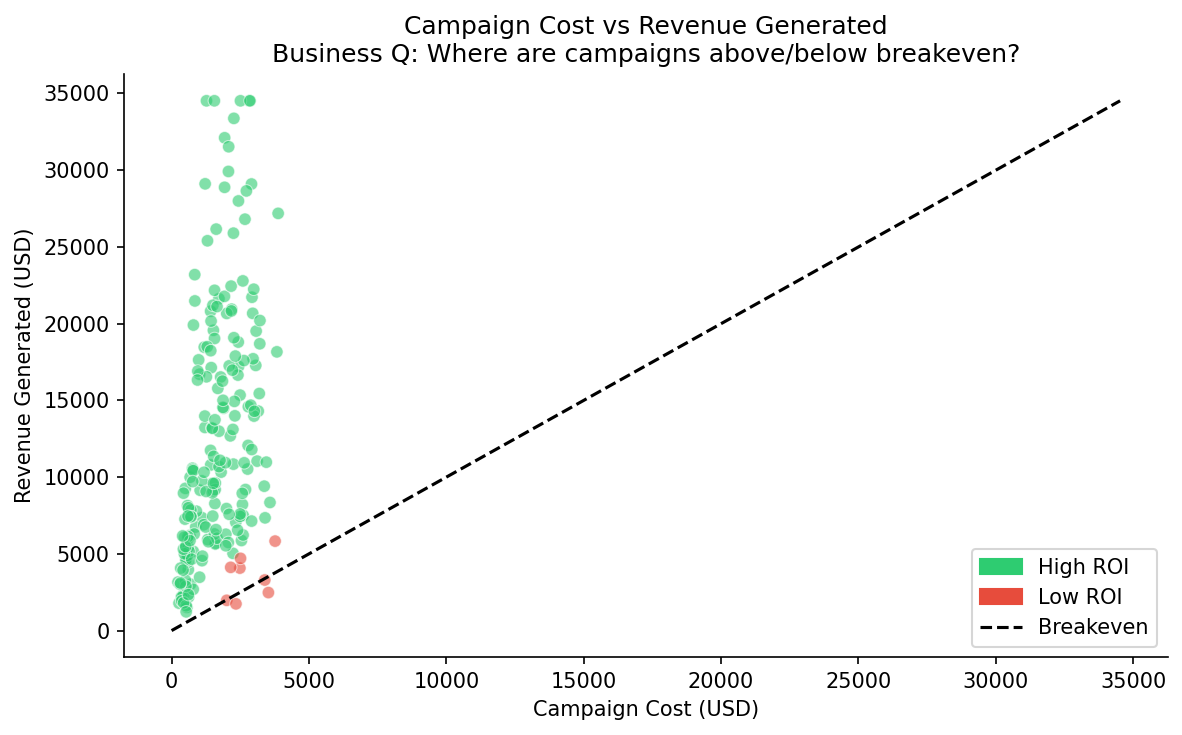

Chart 6 saved.


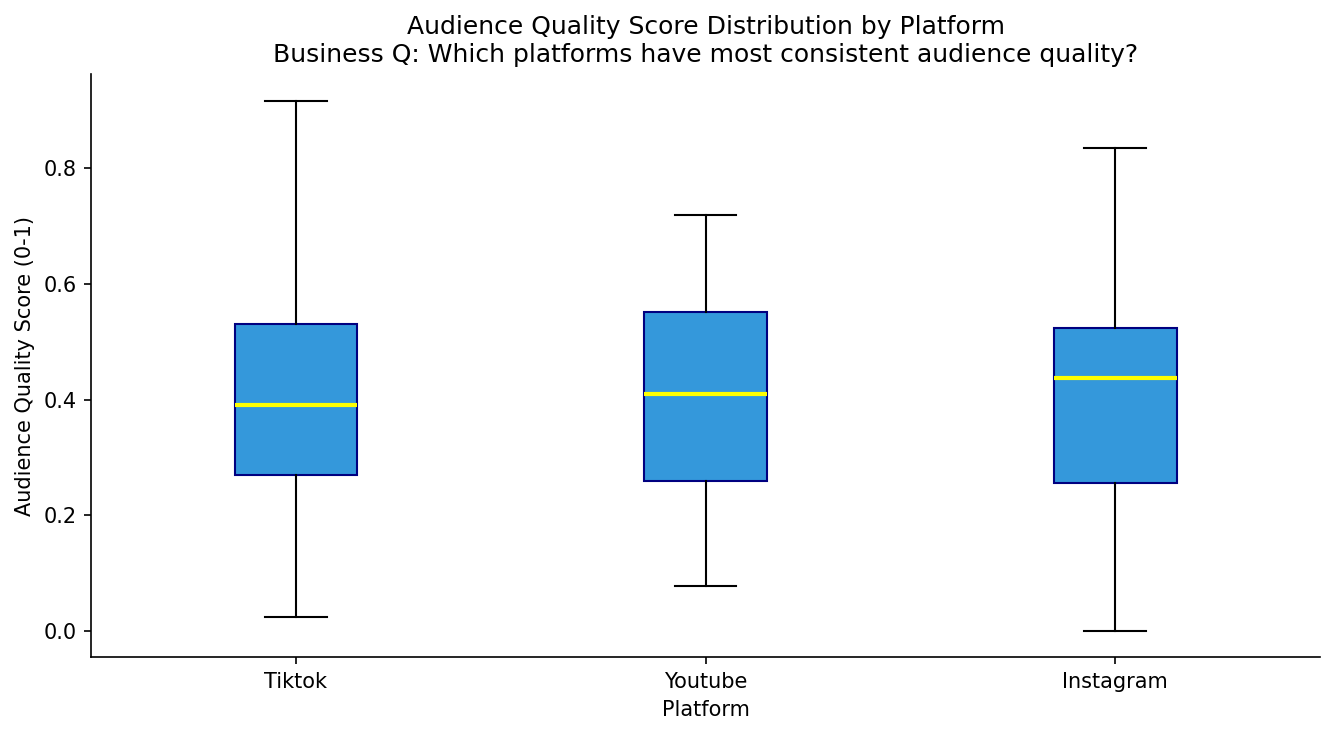

Chart 7 saved.


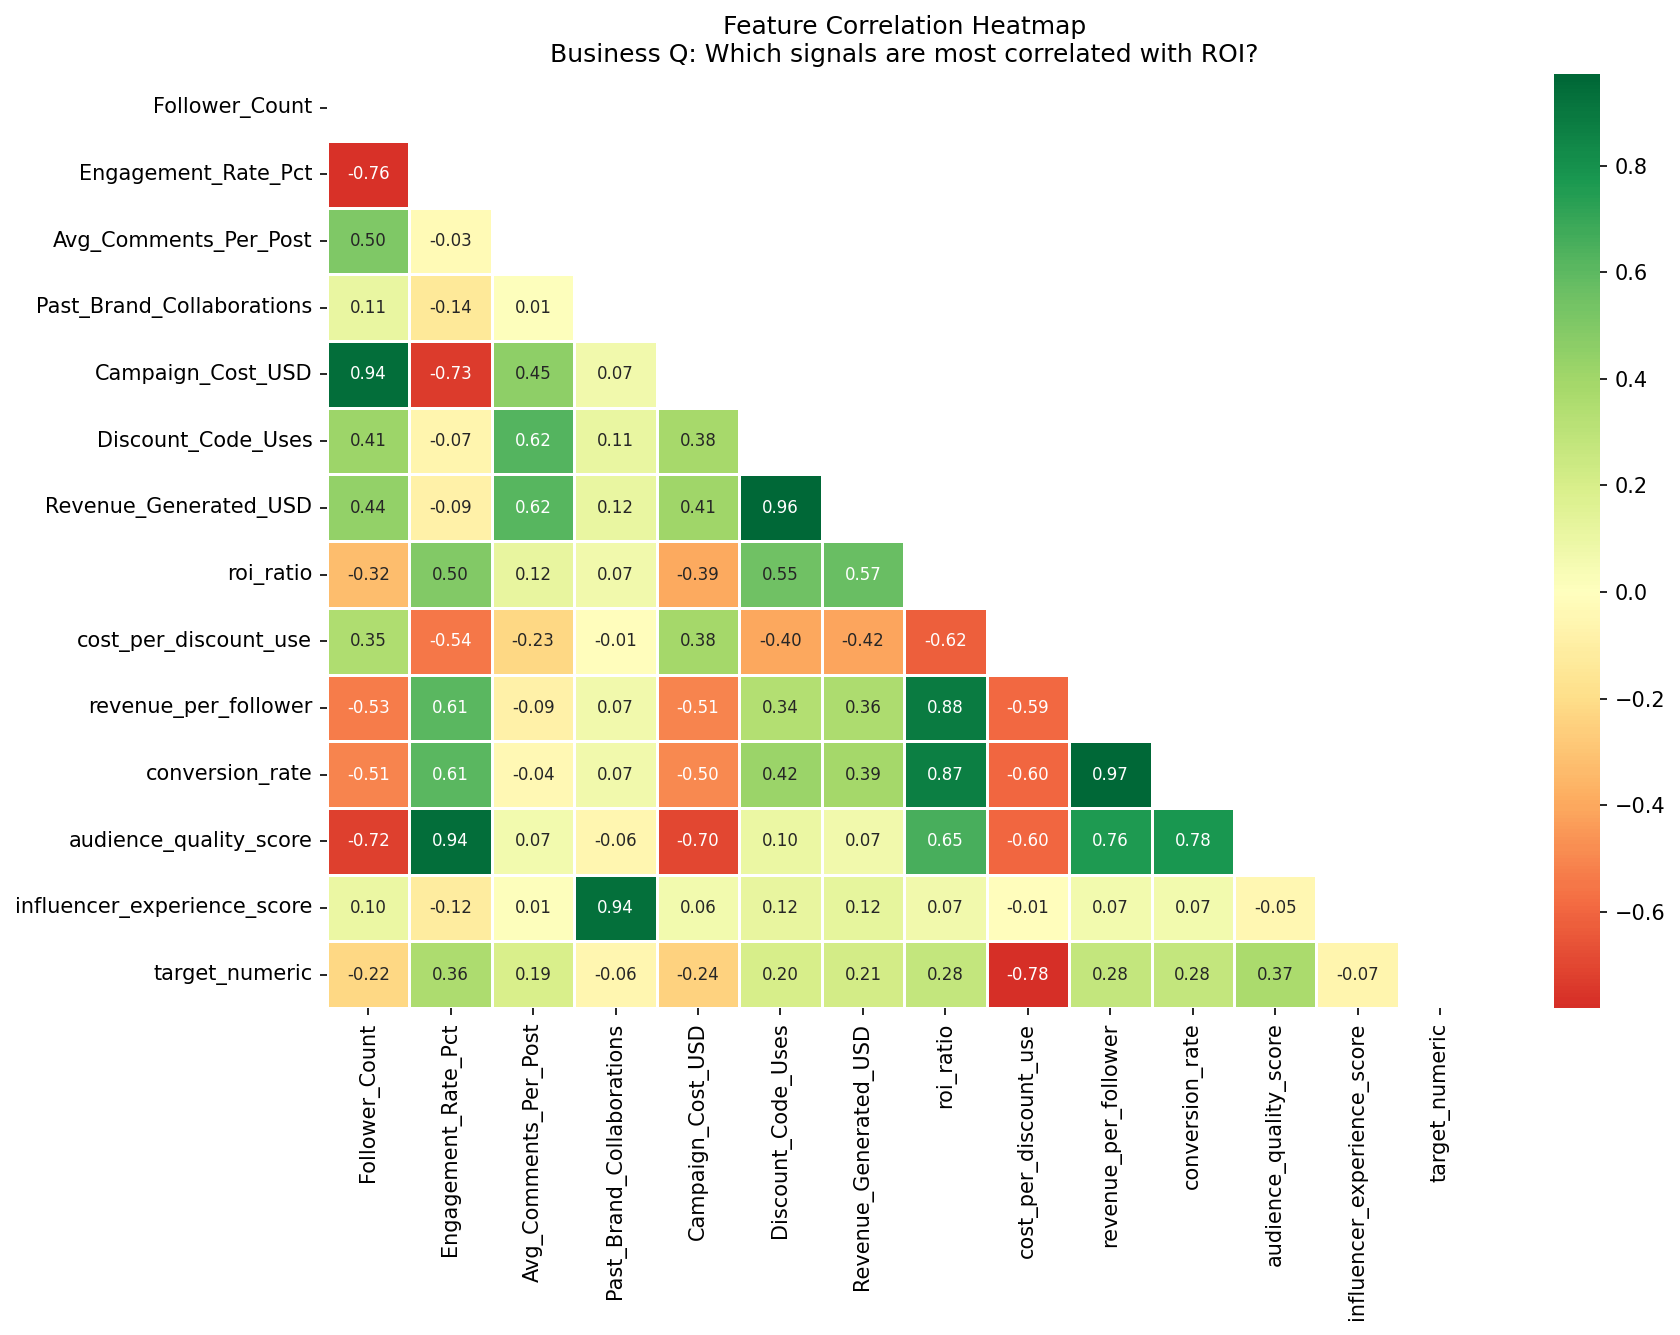

Chart 8 saved.


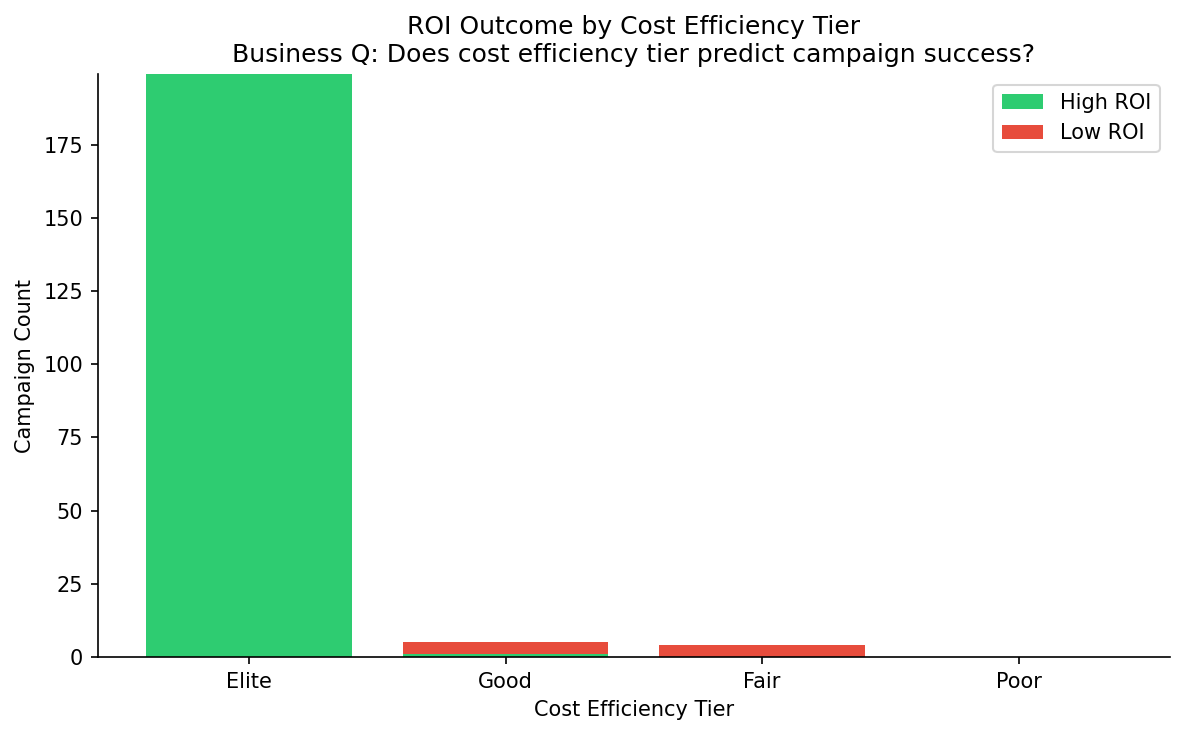

Chart 9 saved.


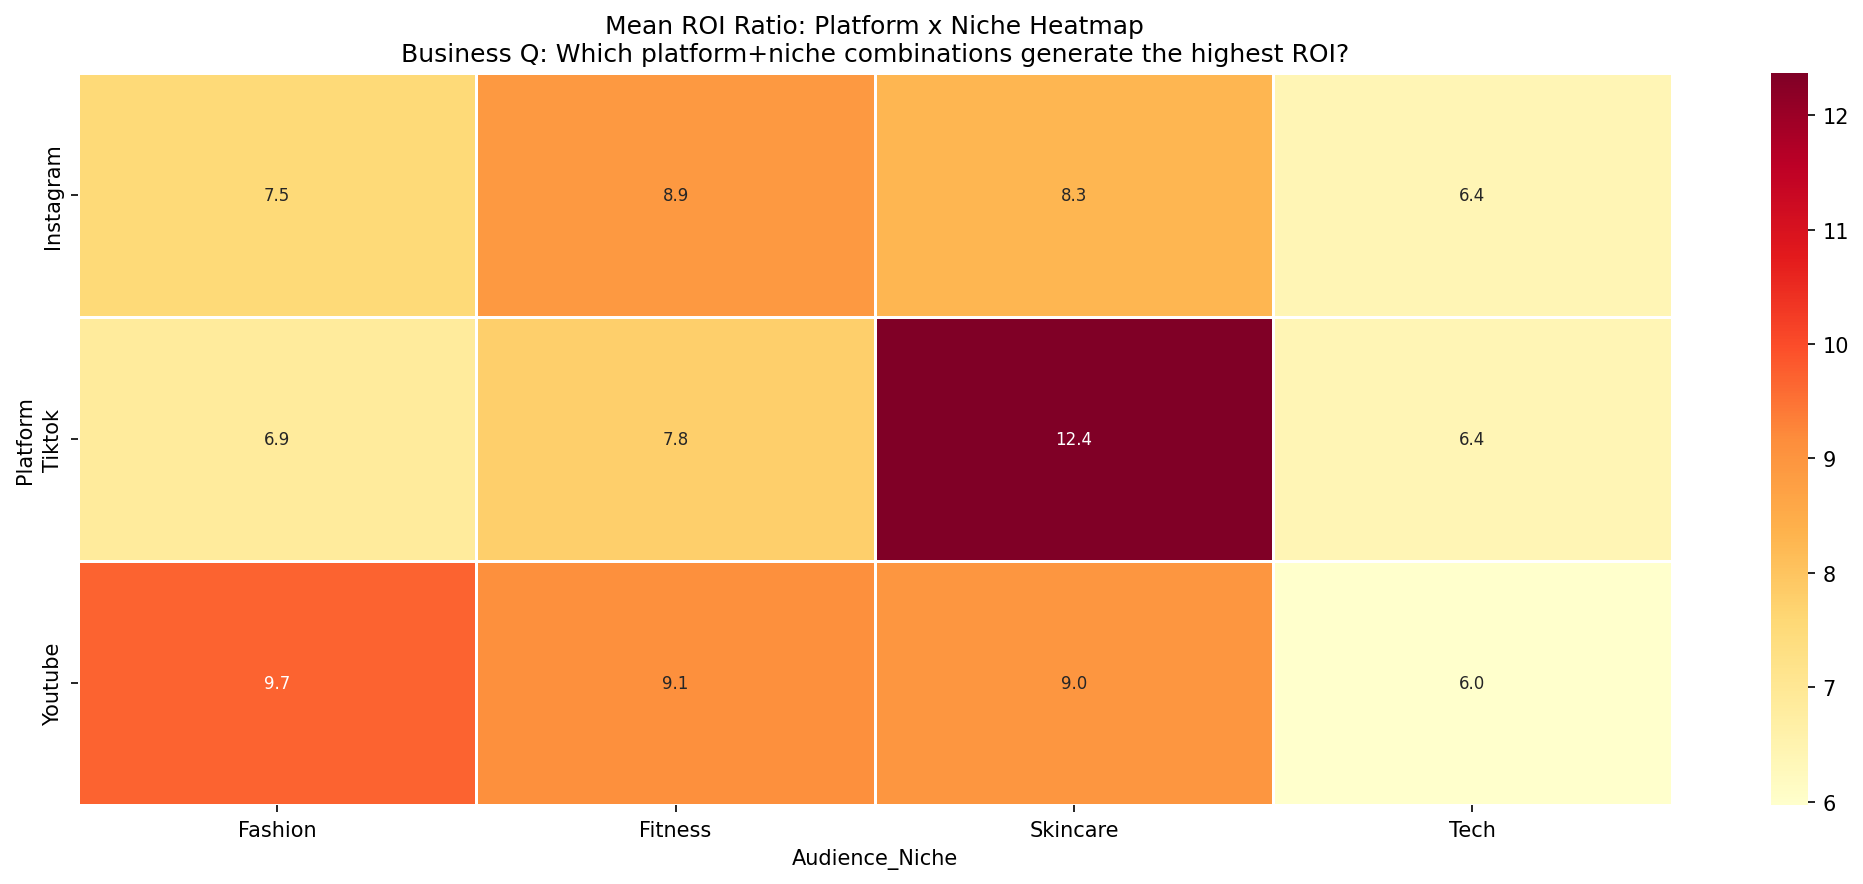

Chart 10 saved.

EDA complete. 10 charts saved to reports/


In [6]:
# [NOTE] src/analytics/eda.py
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np

if 'df_feat' not in dir():
    df_feat = pd.read_csv(CONFIG['FEAT_CSV'])

plt.rcParams.update({'figure.dpi': 150, 'axes.spines.top': False, 'axes.spines.right': False})
RD = CONFIG['REPORTS_DIR']

# Chart 1: ROI Outcome Distribution
fig, ax = plt.subplots(figsize=(7, 4))
vc = df_feat[CONFIG['COL_TARGET']].value_counts()
colors = ['#2ecc71' if k == 'Yes' else '#e74c3c' for k in vc.index]
bars = ax.bar(vc.index, vc.values, color=colors, edgecolor='white', linewidth=1.5)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
            f'{b.get_height()} ({b.get_height()/len(df_feat)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Campaign ROI Outcome Distribution\nBusiness Q: What share of past campaigns delivered high ROI?', fontsize=12)
ax.set_xlabel('ROI Outcome'); ax.set_ylabel('Number of Campaigns')
plt.tight_layout(); plt.savefig(RD+'eda_01_roi_outcome_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("Chart 1 saved.")

# Chart 2: Platform ROI Rate
fig, ax = plt.subplots(figsize=(8, 5))
plat_roi = df_feat.groupby(CONFIG['COL_PLATFORM']).apply(
    lambda x: (x[CONFIG['COL_TARGET']] == 'Yes').mean() * 100
).sort_values(ascending=False)
bars = ax.bar(plat_roi.index, plat_roi.values, color='#3498db', edgecolor='white')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
            f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('High ROI Rate by Platform\nBusiness Q: Which platform produces the most high-ROI campaigns?', fontsize=12)
ax.set_xlabel('Platform'); ax.set_ylabel('% High ROI Campaigns')
ax.set_ylim(0, 100)
plt.tight_layout(); plt.savefig(RD+'eda_02_platform_roi_rate.png', dpi=150, bbox_inches='tight'); plt.show()
print("Chart 2 saved.")

# Chart 3: Niche ROI Rate
fig, ax = plt.subplots(figsize=(9, 5))
niche_roi = df_feat.groupby(CONFIG['COL_NICHE']).apply(
    lambda x: (x[CONFIG['COL_TARGET']] == 'Yes').mean() * 100
).sort_values(ascending=True)
ax.barh(niche_roi.index, niche_roi.values, color='#9b59b6', edgecolor='white')
for i, v in enumerate(niche_roi.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)
ax.set_title('High ROI Rate by Audience Niche\nBusiness Q: Which content niches consistently deliver ROI?', fontsize=12)
ax.set_xlabel('% High ROI Campaigns')
plt.tight_layout(); plt.savefig(RD+'eda_03_niche_roi_rate.png', dpi=150, bbox_inches='tight'); plt.show()
print("Chart 3 saved.")

# Chart 4: Follower Tier vs ROI
fig, ax = plt.subplots(figsize=(8, 5))
tier_order = ['Micro', 'Macro', 'Mega']
tier_high = []
tier_low  = []
for t in tier_order:
    sub = df_feat[df_feat['follower_tier'] == t]
    total = len(sub)
    h = (sub[CONFIG['COL_TARGET']] == 'Yes').sum()
    tier_high.append(h)
    tier_low.append(total - h)
x = range(len(tier_order))
ax.bar(x, tier_high, label='High ROI', color='#2ecc71')
ax.bar(x, tier_low, bottom=tier_high, label='Low ROI', color='#e74c3c')
ax.set_xticks(list(x)); ax.set_xticklabels(tier_order)
ax.set_title('ROI Outcome by Influencer Tier\nBusiness Q: Do micro-influencers outperform mega on ROI?', fontsize=12)
ax.set_xlabel('Follower Tier'); ax.set_ylabel('Campaign Count')
ax.legend()
plt.tight_layout(); plt.savefig(RD+'eda_04_follower_tier_roi.png', dpi=150, bbox_inches='tight'); plt.show()
print("Chart 4 saved.")

# Chart 5: Engagement vs ROI scatter
fig, ax = plt.subplots(figsize=(8, 5))
colors_map = df_feat[CONFIG['COL_TARGET']].map({'Yes': '#2ecc71', 'No': '#e74c3c'})
ax.scatter(df_feat[CONFIG['COL_ENGAGEMENT']], df_feat['roi_ratio'],
           c=colors_map, alpha=0.6, edgecolors='white', linewidth=0.5)
ax.set_title('Engagement Rate vs ROI Ratio\nBusiness Q: Does higher engagement reliably predict higher ROI?', fontsize=12)
ax.set_xlabel('Engagement Rate (%)'); ax.set_ylabel('ROI Ratio (Revenue/Cost)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#2ecc71', label='High ROI'), Patch(color='#e74c3c', label='Low ROI')])
plt.tight_layout(); plt.savefig(RD+'eda_05_engagement_vs_roi_scatter.png', dpi=150, bbox_inches='tight'); plt.show()
print("Chart 5 saved.")

# Chart 6: Cost vs Revenue with breakeven line
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_feat[CONFIG['COL_COST']], df_feat[CONFIG['COL_REVENUE']],
           c=colors_map, alpha=0.6, edgecolors='white', linewidth=0.5)
max_val = max(df_feat[CONFIG['COL_COST']].max(), df_feat[CONFIG['COL_REVENUE']].max())
ax.plot([0, max_val], [0, max_val], 'k--', lw=1.5, label='Breakeven (1x ROI)')
ax.set_title('Campaign Cost vs Revenue Generated\nBusiness Q: Where are campaigns above/below breakeven?', fontsize=12)
ax.set_xlabel('Campaign Cost (USD)'); ax.set_ylabel('Revenue Generated (USD)')
ax.legend(handles=[Patch(color='#2ecc71', label='High ROI'),
                   Patch(color='#e74c3c', label='Low ROI'),
                   plt.Line2D([0],[0], color='k', linestyle='--', label='Breakeven')])
plt.tight_layout(); plt.savefig(RD+'eda_06_cost_vs_revenue_scatter.png', dpi=150, bbox_inches='tight'); plt.show()
print("Chart 6 saved.")

# Chart 7: Audience Quality Score by Platform (box)
fig, ax = plt.subplots(figsize=(9, 5))
plat_groups = [df_feat[df_feat[CONFIG['COL_PLATFORM']] == p]['audience_quality_score'].dropna().values
               for p in df_feat[CONFIG['COL_PLATFORM']].unique()]
plat_labels = list(df_feat[CONFIG['COL_PLATFORM']].unique())
ax.boxplot(plat_groups, labels=plat_labels, patch_artist=True,
           boxprops=dict(facecolor='#3498db', color='navy'),
           medianprops=dict(color='yellow', linewidth=2))
ax.set_title('Audience Quality Score Distribution by Platform\nBusiness Q: Which platforms have most consistent audience quality?', fontsize=12)
ax.set_xlabel('Platform'); ax.set_ylabel('Audience Quality Score (0-1)')
plt.tight_layout(); plt.savefig(RD+'eda_07_audience_quality_by_platform.png', dpi=150, bbox_inches='tight'); plt.show()
print("Chart 7 saved.")

# Chart 8: Correlation Heatmap
numeric_cols = ['Follower_Count','Engagement_Rate_Pct','Avg_Comments_Per_Post',
                'Past_Brand_Collaborations','Campaign_Cost_USD','Discount_Code_Uses',
                'Revenue_Generated_USD','roi_ratio','cost_per_discount_use',
                'revenue_per_follower','conversion_rate','audience_quality_score',
                'influencer_experience_score','target_numeric']
avail = [c for c in numeric_cols if c in df_feat.columns]
corr = df_feat[avail].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap\nBusiness Q: Which signals are most correlated with ROI?', fontsize=12)
plt.tight_layout(); plt.savefig(RD+'eda_08_correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
print("Chart 8 saved.")

# Chart 9: Cost Efficiency Tier vs ROI
fig, ax = plt.subplots(figsize=(8, 5))
tier_labels = ['Elite', 'Good', 'Fair', 'Poor']
tier_high2, tier_low2 = [], []
for t in tier_labels:
    sub = df_feat[df_feat['cost_efficiency_tier'] == t]
    h = (sub[CONFIG['COL_TARGET']] == 'Yes').sum()
    tier_high2.append(h)
    tier_low2.append(len(sub) - h)
x2 = range(len(tier_labels))
ax.bar(x2, tier_high2, label='High ROI', color='#2ecc71')
ax.bar(x2, tier_low2, bottom=tier_high2, label='Low ROI', color='#e74c3c')
ax.set_xticks(list(x2)); ax.set_xticklabels(tier_labels)
ax.set_title('ROI Outcome by Cost Efficiency Tier\nBusiness Q: Does cost efficiency tier predict campaign success?', fontsize=12)
ax.set_xlabel('Cost Efficiency Tier'); ax.set_ylabel('Campaign Count')
ax.legend()
plt.tight_layout(); plt.savefig(RD+'eda_09_cost_efficiency_tier_breakdown.png', dpi=150, bbox_inches='tight'); plt.show()
print("Chart 9 saved.")

# Chart 10: Platform x Niche ROI Heatmap
try:
    pivot = df_feat.pivot_table(values='roi_ratio', index=CONFIG['COL_PLATFORM'],
                                 columns=CONFIG['COL_NICHE'], aggfunc='mean')
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
                linewidths=0.5, annot_kws={'size': 8})
    ax.set_title('Mean ROI Ratio: Platform x Niche Heatmap\nBusiness Q: Which platform+niche combinations generate the highest ROI?', fontsize=12)
    plt.tight_layout(); plt.savefig(RD+'eda_10_platform_niche_roi_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
    print("Chart 10 saved.")
except Exception as e:
    print("Chart 10 skipped:", e)

print("\nEDA complete. 10 charts saved to", RD)


## Phase 5 — ROI Prediction Model: Will This Campaign Deliver?

Rule-based baseline accuracy: 0.8571
Logistic Regression: CV-AUC=0.9969+/-0.0063 | Test-AUC=1.0000 | Test-Acc=0.9762 | F1=0.9877
Random Forest: CV-AUC=1.0000+/-0.0000 | Test-AUC=1.0000 | Test-Acc=1.0000 | F1=1.0000
Gradient Boosting: CV-AUC=1.0000+/-0.0000 | Test-AUC=1.0000 | Test-Acc=1.0000 | F1=1.0000

Best model: Logistic Regression
Models saved.


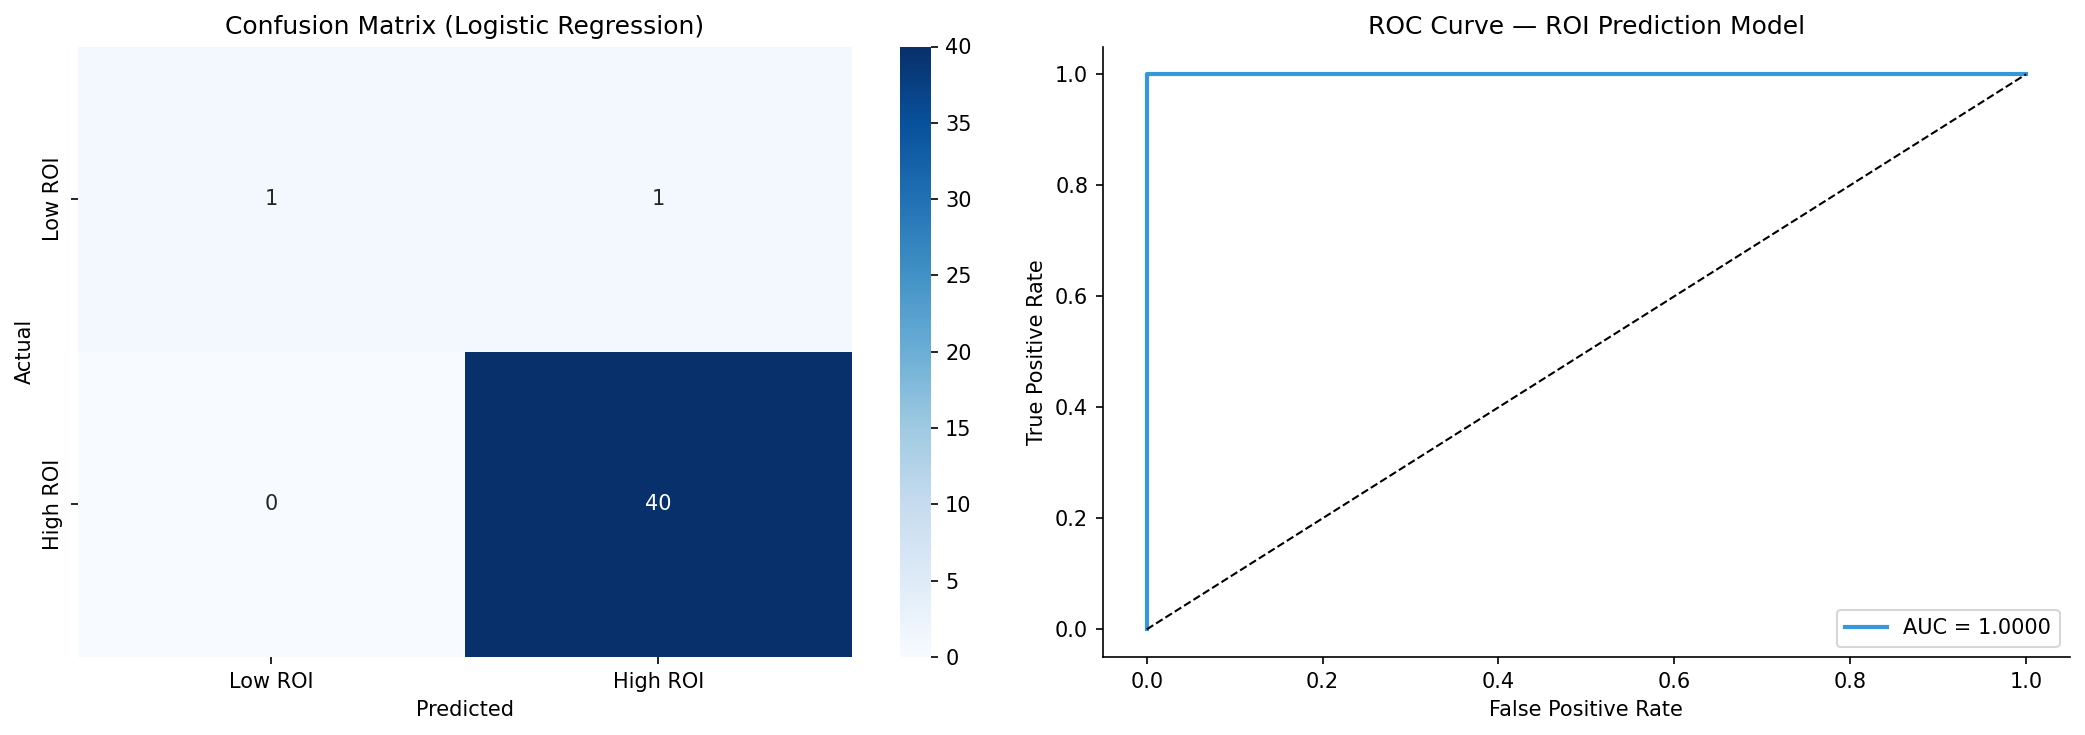

Classifier eval chart saved.


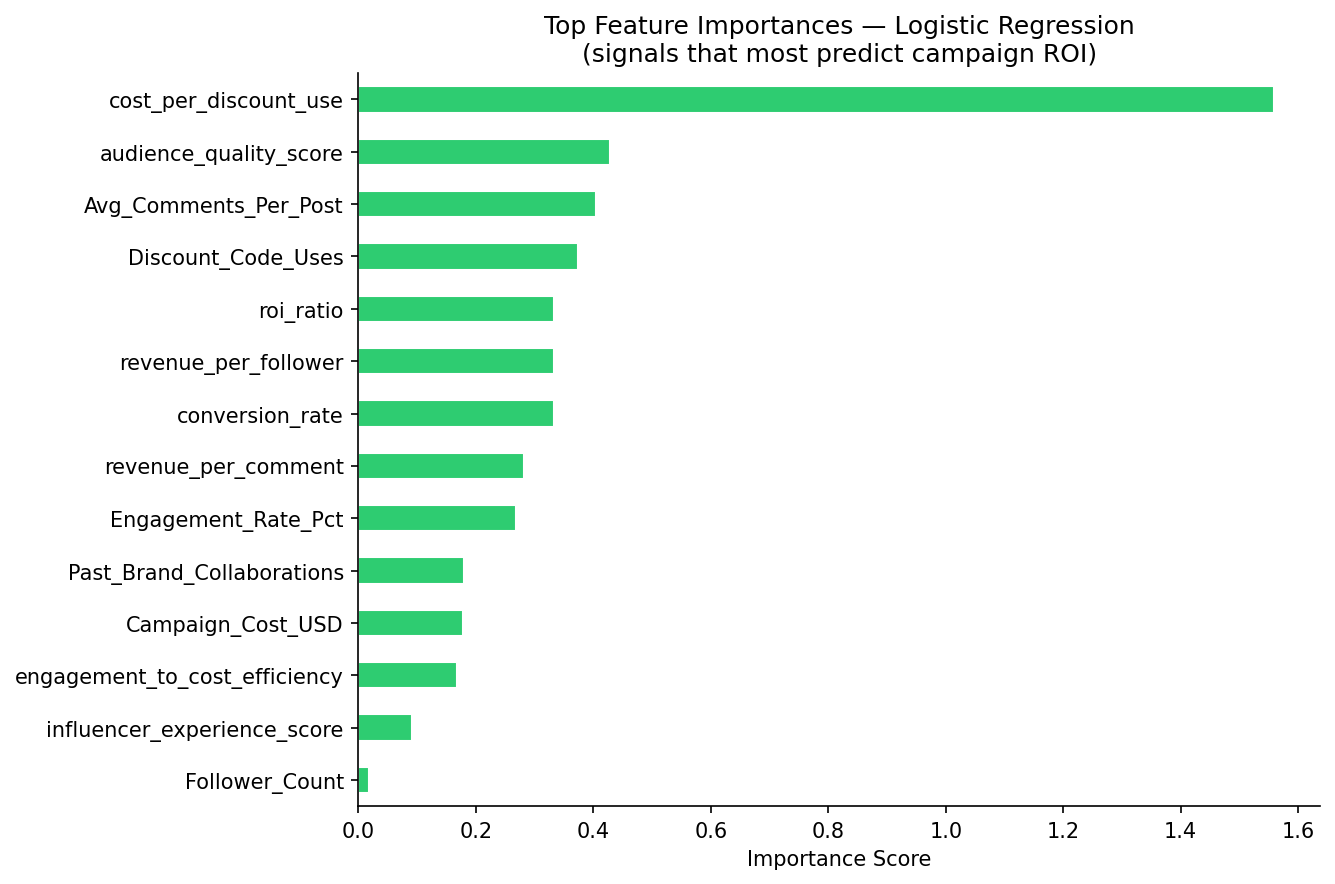

Feature importance chart saved.

Classification Report:
              precision    recall  f1-score   support

     Low ROI       1.00      0.50      0.67         2
    High ROI       0.98      1.00      0.99        40

    accuracy                           0.98        42
   macro avg       0.99      0.75      0.83        42
weighted avg       0.98      0.98      0.97        42



In [7]:
# [NOTE] src/models/classify.py
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                              classification_report, confusion_matrix, roc_curve)
import joblib

if 'df_feat' not in dir():
    df_feat = pd.read_csv(CONFIG['FEAT_CSV'])

FEATURE_COLS = [
    'Follower_Count', 'Engagement_Rate_Pct', 'Avg_Comments_Per_Post',
    'Past_Brand_Collaborations', 'Campaign_Cost_USD', 'Discount_Code_Uses',
    'roi_ratio', 'cost_per_discount_use', 'revenue_per_follower',
    'conversion_rate', 'engagement_to_cost_efficiency',
    'audience_quality_score', 'influencer_experience_score', 'revenue_per_comment',
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_feat.columns]

X = df_feat[FEATURE_COLS].fillna(0)
y = df_feat['target_numeric'].fillna(0).astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=CONFIG['TEST_SIZE'],
    random_state=CONFIG['RANDOM_STATE'], stratify=y
)
assert len(X_tr) >= 20, "Training set too small"

# Rule-based baseline
baseline_preds = (df_feat.loc[y_te.index, 'roi_ratio'] >= CONFIG['ROI_HIGH_THRESHOLD']).astype(int)
print(f"Rule-based baseline accuracy: {accuracy_score(y_te, baseline_preds):.4f}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=CONFIG['RANDOM_STATE'])

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=CONFIG['RANDOM_STATE']))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=CONFIG['RANDOM_STATE'], n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, random_state=CONFIG['RANDOM_STATE']
    ),
}

results = {}
for name, mdl in models.items():
    cv_auc = cross_val_score(mdl, X_tr, y_tr, cv=skf, scoring='roc_auc')
    mdl.fit(X_tr, y_tr)
    y_pred = mdl.predict(X_te)
    y_prob = mdl.predict_proba(X_te)[:, 1]
    test_auc = roc_auc_score(y_te, y_prob)
    test_acc = accuracy_score(y_te, y_pred)
    test_f1  = f1_score(y_te, y_pred)
    results[name] = {
        'model': mdl, 'cv_auc_mean': cv_auc.mean(), 'cv_auc_std': cv_auc.std(),
        'test_auc': test_auc, 'test_acc': test_acc, 'test_f1': test_f1,
        'y_prob': y_prob, 'y_pred': y_pred,
    }
    print(f"{name}: CV-AUC={cv_auc.mean():.4f}+/-{cv_auc.std():.4f} | Test-AUC={test_auc:.4f} | Test-Acc={test_acc:.4f} | F1={test_f1:.4f}")

best_name = max(results, key=lambda k: results[k]['test_auc'])
best = results[best_name]
best_model = best['model']
print(f"\nBest model: {best_name}")

joblib.dump(best_model, CONFIG['MODELS_DIR'] + 'roi_classifier.pkl')
joblib.dump(FEATURE_COLS, CONFIG['MODELS_DIR'] + 'feature_cols.pkl')
print("Models saved.")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_te, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low ROI', 'High ROI'],
            yticklabels=['Low ROI', 'High ROI'])
axes[0].set_title(f'Confusion Matrix ({best_name})')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_te, best['y_prob'])
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {best["test_auc"]:.4f}', color='#3498db')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_title('ROC Curve — ROI Prediction Model')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
plt.tight_layout()
plt.savefig(CONFIG['REPORTS_DIR']+'ml_01_classifier_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print("Classifier eval chart saved.")

# Feature importance (tree models)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'named_steps') and hasattr(best_model.named_steps.get('clf', None), 'coef_'):
    importances = abs(best_model.named_steps['clf'].coef_[0])
else:
    importances = np.zeros(len(FEATURE_COLS))

fi = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(9, 6))
fi.plot(kind='barh', ax=ax, color='#2ecc71', edgecolor='white')
ax.set_title(f'Top Feature Importances — {best_name}\n(signals that most predict campaign ROI)', fontsize=12)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(CONFIG['REPORTS_DIR']+'ml_02_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance chart saved.")

df_feat['pred_high_roi'] = best_model.predict(df_feat[FEATURE_COLS].fillna(0))
df_feat['pred_roi_probability'] = best_model.predict_proba(df_feat[FEATURE_COLS].fillna(0))[:, 1]

print("\nClassification Report:")
print(classification_report(y_te, best['y_pred'], target_names=['Low ROI', 'High ROI']))

BEST_MODEL_NAME = best_name
BEST_AUC = best['test_auc']


## Phase 6 — Influencer Segmentation & Anomaly Detection: The Tier Matrix

  File "c:\Users\91635\OneDrive\VS STUDIO\.venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


Influencer Tier Distribution:
                 count  mean_roi  mean_engagement  mean_aq_score  \
influencer_tier                                                    
Bronze Tier         32     2.543            3.366          0.157   
Gold Tier           68    14.075            8.782          0.570   
Silver Tier        108     6.612            6.465          0.361   

                 mean_cost_per_use  
influencer_tier                     
Bronze Tier                 25.354  
Gold Tier                    4.001  
Silver Tier                  8.658  

Anomaly Detection: 17/208 campaigns flagged (8.2%)
Anomalous campaign High ROI rate: 58.8%
Note: These campaigns warrant manual review — unusual spend or revenue patterns detected
Models saved.


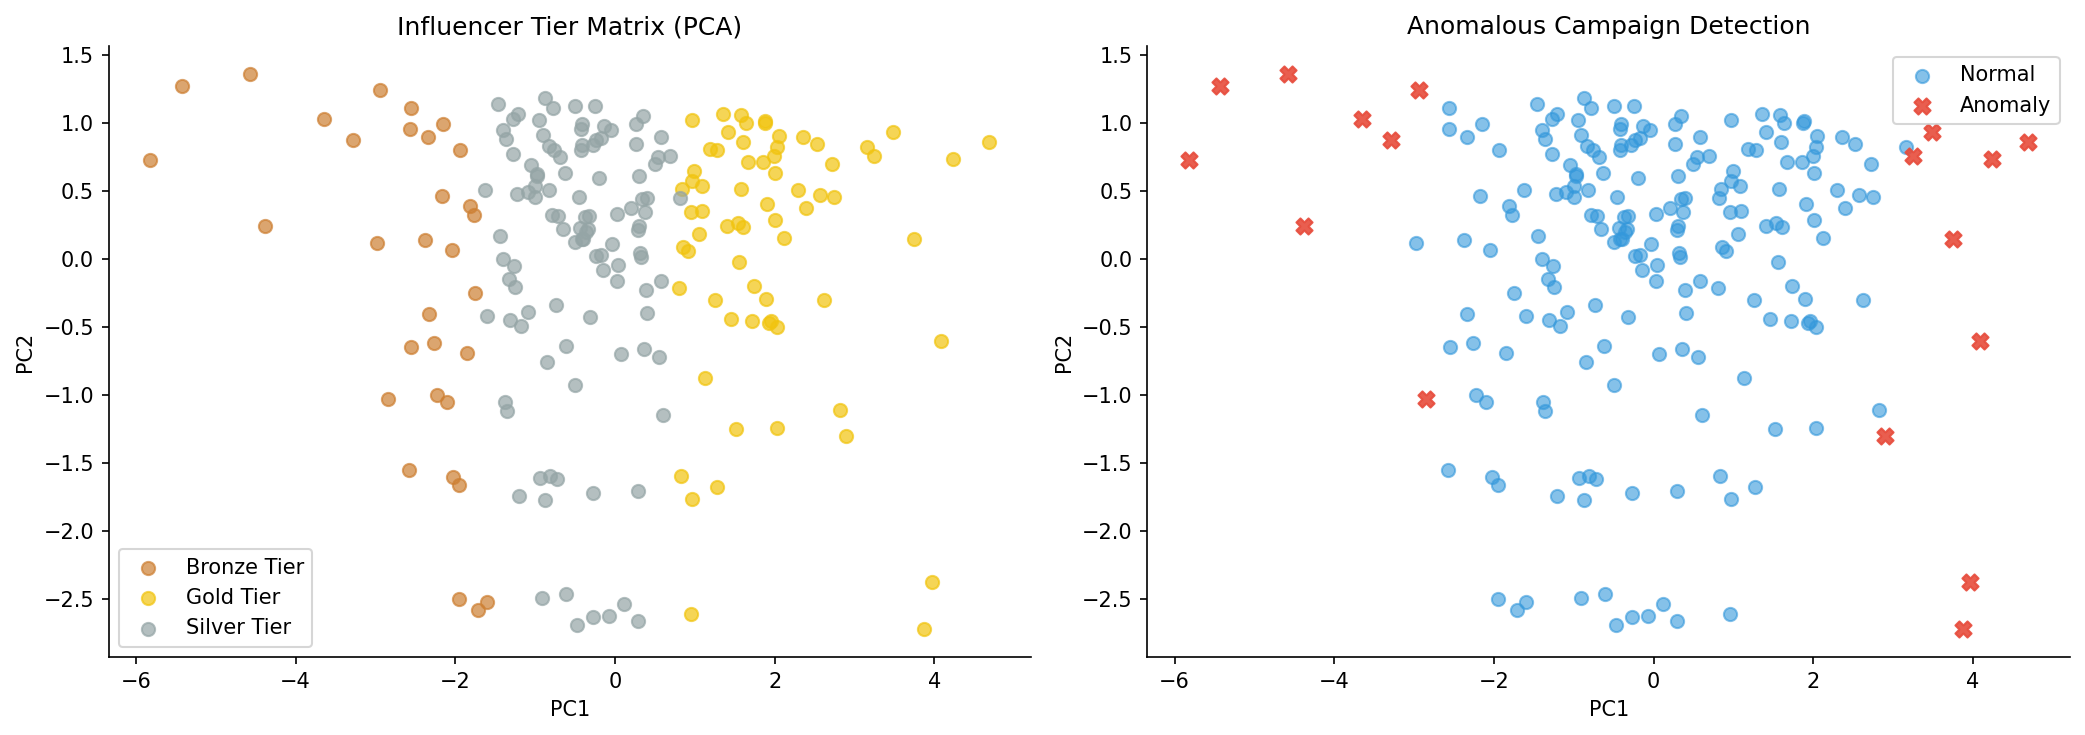

Segmentation chart saved.
df_feat saved with tier + anomaly columns.


In [8]:
# [NOTE] src/models/segment.py
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
import joblib

if 'df_feat' not in dir():
    df_feat = pd.read_csv(CONFIG['FEAT_CSV'])

SEG_FEATURES = ['audience_quality_score', 'roi_ratio', 'conversion_rate',
                'influencer_experience_score', 'cost_per_discount_use']
SEG_FEATURES = [c for c in SEG_FEATURES if c in df_feat.columns]

X_seg = df_feat[SEG_FEATURES].fillna(0)
scaler_seg = StandardScaler()
X_seg_sc = scaler_seg.fit_transform(X_seg)

km = KMeans(n_clusters=3, n_init=10, random_state=CONFIG['RANDOM_STATE'])
km.fit(X_seg_sc)
df_feat['_km_label'] = km.labels_

# Label clusters by mean roi_ratio
cluster_roi = df_feat.groupby('_km_label')['roi_ratio'].mean().sort_values(ascending=False)
tier_map = {}
tier_names = ['Gold Tier', 'Silver Tier', 'Bronze Tier']
for rank, (cluster_id, _) in enumerate(cluster_roi.items()):
    tier_map[cluster_id] = tier_names[rank]

df_feat['influencer_tier'] = df_feat['_km_label'].map(tier_map)
df_feat.drop(columns=['_km_label'], inplace=True)

print("Influencer Tier Distribution:")
tier_summary = df_feat.groupby('influencer_tier').agg(
    count=('roi_ratio', 'count'),
    mean_roi=('roi_ratio', 'mean'),
    mean_engagement=('Engagement_Rate_Pct', 'mean'),
    mean_aq_score=('audience_quality_score', 'mean'),
    mean_cost_per_use=('cost_per_discount_use', 'mean')
).round(3)
print(tier_summary)

# PCA for visualisation
pca = PCA(n_components=2, random_state=CONFIG['RANDOM_STATE'])
X_pca = pca.fit_transform(X_seg_sc)

# Isolation Forest anomaly detection
iso = IsolationForest(contamination=0.08, random_state=CONFIG['RANDOM_STATE'])
df_feat['is_campaign_anomaly'] = (iso.fit_predict(X_seg_sc) == -1).astype(int)

anomaly_count = df_feat['is_campaign_anomaly'].sum()
total = len(df_feat)
anomaly_high_roi = df_feat[df_feat['is_campaign_anomaly'] == 1][CONFIG['COL_TARGET']].eq('Yes').mean()
print(f"\nAnomaly Detection: {anomaly_count}/{total} campaigns flagged ({anomaly_count/total*100:.1f}%)")
print(f"Anomalous campaign High ROI rate: {anomaly_high_roi*100:.1f}%")
print("Note: These campaigns warrant manual review — unusual spend or revenue patterns detected")

joblib.dump(iso, CONFIG['MODELS_DIR'] + 'campaign_anomaly_detector.pkl')
joblib.dump(km, CONFIG['MODELS_DIR'] + 'influencer_segmenter.pkl')
joblib.dump(scaler_seg, CONFIG['MODELS_DIR'] + 'seg_scaler.pkl')
print("Models saved.")

# Plot: cluster + anomaly side by side
tier_color_map = {'Gold Tier': '#f1c40f', 'Silver Tier': '#95a5a6', 'Bronze Tier': '#cd7f32'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for tier, grp in df_feat.groupby('influencer_tier'):
    idx = grp.index
    axes[0].scatter(X_pca[idx, 0], X_pca[idx, 1],
                    c=tier_color_map.get(tier, 'grey'), label=tier, alpha=0.7, s=40)
axes[0].set_title('Influencer Tier Matrix (PCA)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend()

norm_mask = df_feat['is_campaign_anomaly'] == 0
anom_mask = df_feat['is_campaign_anomaly'] == 1
axes[1].scatter(X_pca[norm_mask, 0], X_pca[norm_mask, 1],
                c='#3498db', label='Normal', alpha=0.6, s=40)
axes[1].scatter(X_pca[anom_mask, 0], X_pca[anom_mask, 1],
                c='#e74c3c', label='Anomaly', alpha=0.9, s=60, marker='X')
axes[1].set_title('Anomalous Campaign Detection')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend()

plt.tight_layout()
plt.savefig(CONFIG['REPORTS_DIR']+'ml_03_influencer_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("Segmentation chart saved.")

df_feat.to_csv(CONFIG['FEAT_CSV'], index=False, encoding='utf-8')
print("df_feat saved with tier + anomaly columns.")


## Phase 7 — Revenue Forecasting: Predicted Revenue Per Campaign

Revenue Forecaster:
  MAE  = $812.85
  R2   = 0.9819
  MAPE = 7.89%
revenue_forecaster.pkl saved.

Platform Revenue Summary:
           campaigns  mean_revenue  mean_cost  mean_roi_ratio  pct_high_roi
Platform                                                                   
Tiktok           100      12990.49    1673.38            8.76         97.00
Youtube           32      12044.57    1640.15            8.69         96.88
Instagram         76      11362.28    1682.78            7.87         94.74

Niche Revenue Summary:
                campaigns  mean_revenue  mean_cost  mean_roi_ratio  pct_high_roi
Audience_Niche                                                                  
Skincare               66      15873.07    1789.04           10.31         98.48
Fitness                42      12284.88    1665.39            8.25         92.86
Fashion                77       9959.22    1534.98            7.54         97.40
Tech                   23       9459.15    1804.26            6.29

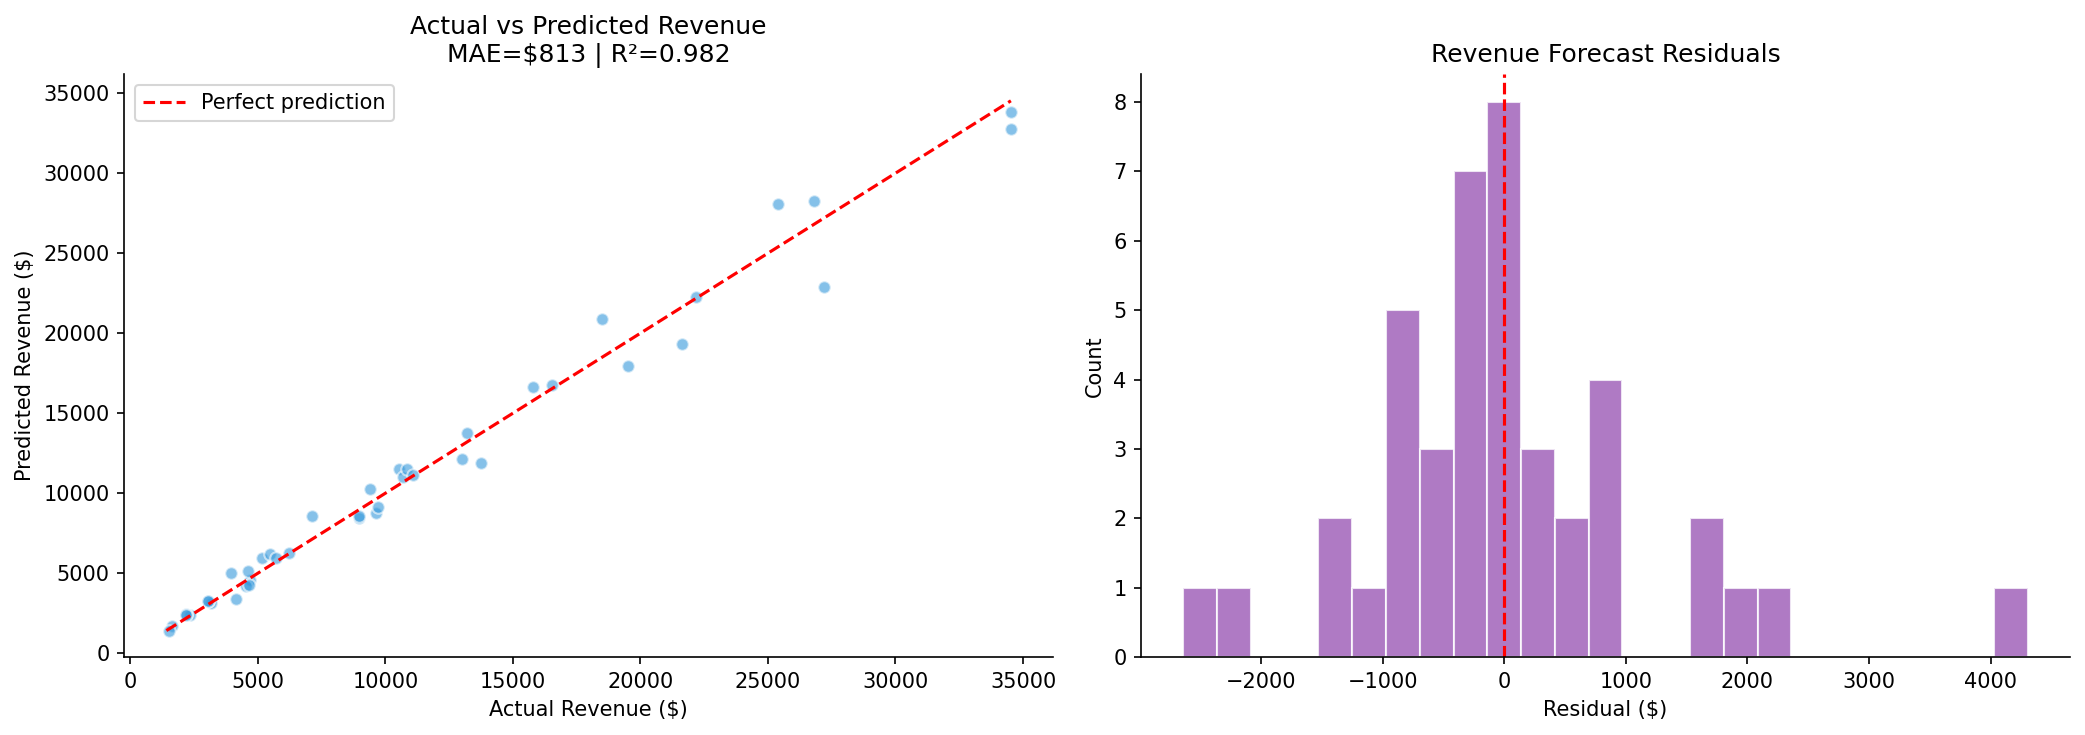

Revenue forecast chart saved.


In [9]:
# [NOTE] src/models/forecast.py
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib, numpy as np

if 'df_feat' not in dir():
    df_feat = pd.read_csv(CONFIG['FEAT_CSV'])

# Exclude roi_ratio — it contains Revenue in its numerator (data leakage)
REG_FEATURE_COLS = [
    'Follower_Count', 'Engagement_Rate_Pct', 'Avg_Comments_Per_Post',
    'Past_Brand_Collaborations', 'Campaign_Cost_USD', 'Discount_Code_Uses',
    'cost_per_discount_use', 'revenue_per_follower', 'conversion_rate',
    'engagement_to_cost_efficiency', 'audience_quality_score',
    'influencer_experience_score', 'revenue_per_comment',
]
REG_FEATURE_COLS = [c for c in REG_FEATURE_COLS if c in df_feat.columns]

X_reg = df_feat[REG_FEATURE_COLS].fillna(0)
y_reg = df_feat[CONFIG['COL_REVENUE']].fillna(0)

from sklearn.model_selection import train_test_split
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=CONFIG['TEST_SIZE'],
    random_state=CONFIG['RANDOM_STATE']
)
assert len(X_tr_r) >= 20, "Training set too small"

gb_reg = GradientBoostingRegressor(n_estimators=200, random_state=CONFIG['RANDOM_STATE'])
gb_reg.fit(X_tr_r, y_tr_r)
y_pred_r = gb_reg.predict(X_te_r)

mae = mean_absolute_error(y_te_r, y_pred_r)
r2  = r2_score(y_te_r, y_pred_r)
mape_vals = np.abs((y_te_r - y_pred_r) / y_te_r.replace(0, 1)) * 100
mape = mape_vals.mean()

print(f"Revenue Forecaster:")
print(f"  MAE  = ${mae:,.2f}")
print(f"  R2   = {r2:.4f}")
print(f"  MAPE = {mape:.2f}%")

joblib.dump(gb_reg, CONFIG['MODELS_DIR'] + 'revenue_forecaster.pkl')
print("revenue_forecaster.pkl saved.")

df_feat['predicted_revenue_usd'] = gb_reg.predict(X_reg)

# Summary tables
print("\nPlatform Revenue Summary:")
plat_summary = df_feat.groupby(CONFIG['COL_PLATFORM']).agg(
    campaigns=('roi_ratio', 'count'),
    mean_revenue=('Revenue_Generated_USD', 'mean'),
    mean_cost=('Campaign_Cost_USD', 'mean'),
    mean_roi_ratio=('roi_ratio', 'mean'),
    pct_high_roi=(CONFIG['COL_TARGET'], lambda x: (x == 'Yes').mean() * 100)
).round(2).sort_values('mean_roi_ratio', ascending=False)
print(plat_summary.to_string())

print("\nNiche Revenue Summary:")
niche_summary = df_feat.groupby(CONFIG['COL_NICHE']).agg(
    campaigns=('roi_ratio', 'count'),
    mean_revenue=('Revenue_Generated_USD', 'mean'),
    mean_cost=('Campaign_Cost_USD', 'mean'),
    mean_roi_ratio=('roi_ratio', 'mean'),
    pct_high_roi=(CONFIG['COL_TARGET'], lambda x: (x == 'Yes').mean() * 100)
).round(2).sort_values('mean_roi_ratio', ascending=False)
print(niche_summary.to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_te_r, y_pred_r, alpha=0.6, color='#3498db', edgecolors='white')
mn = min(y_te_r.min(), y_pred_r.min())
mx = max(y_te_r.max(), y_pred_r.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_title(f'Actual vs Predicted Revenue\nMAE=${mae:,.0f} | R²={r2:.3f}')
axes[0].set_xlabel('Actual Revenue ($)'); axes[0].set_ylabel('Predicted Revenue ($)')
axes[0].legend()

residuals = y_te_r.values - y_pred_r
axes[1].hist(residuals, bins=25, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Revenue Forecast Residuals')
axes[1].set_xlabel('Residual ($)'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(CONFIG['REPORTS_DIR']+'ml_04_revenue_forecast_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print("Revenue forecast chart saved.")

REVENUE_MAE = mae
REVENUE_R2  = r2


## Phase 8 — Campaign Intelligence Engine: Automated Scoring & Alerts

Partnership Priority Distribution:
                      count  mean_roi
partnership_priority                 
P1_STRATEGIC_PARTNER    143    10.178
P2_RECOMMENDED           50     5.348
P3_MONITOR               11     2.386
P4_REVIEW_REQUIRED        1     0.972
P5_DO_NOT_REBOOK          3     0.810


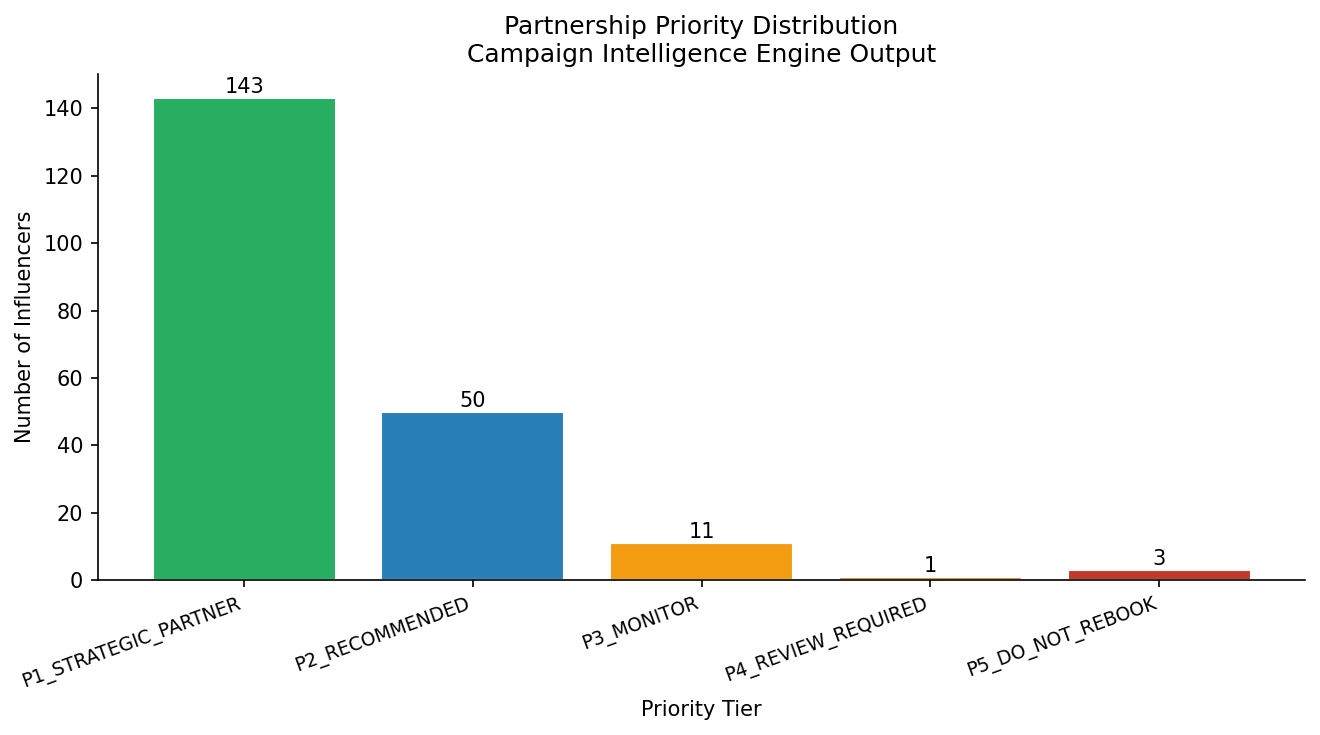

Priority distribution chart saved.
df_feat saved with business intelligence columns.


In [10]:
# [NOTE] src/analytics/business.py
if 'df_feat' not in dir():
    df_feat = pd.read_csv(CONFIG['FEAT_CSV'])

THRESHOLDS = {
    'roi_high':              CONFIG['ROI_HIGH_THRESHOLD'],
    'roi_medium':            CONFIG['ROI_MEDIUM_THRESHOLD'],
    'engagement_high':       CONFIG['ENGAGEMENT_HIGH'],
    'engagement_low':        1.0,
    'cost_per_use_good':     CONFIG['COST_PER_USE_THRESHOLD'],
    'cost_per_use_alarm':    200.0,
    'conversion_good':       CONFIG['CONVERSION_RATE_GOOD'],
    'experience_low':        2,
    'audience_quality_high': 0.7,
}

def assign_campaign_alerts(row):
    alerts = []
    roi = row.get('roi_ratio', 0)
    eng = row.get('Engagement_Rate_Pct', 0)
    aq  = row.get('audience_quality_score', 0)
    cpu = row.get('cost_per_discount_use', 9999)
    cr  = row.get('conversion_rate', 0)
    duc = row.get('Discount_Code_Uses', 0)
    col = row.get('Past_Brand_Collaborations', 0)
    ano = row.get('is_campaign_anomaly', 0)

    if roi >= THRESHOLDS['roi_high']:             alerts.append('HIGH_ROI_CONFIRMED')
    if eng >= THRESHOLDS['engagement_high']:      alerts.append('STRONG_ENGAGEMENT')
    if aq  >= THRESHOLDS['audience_quality_high']:alerts.append('ELITE_AUDIENCE_QUALITY')
    if cpu <= THRESHOLDS['cost_per_use_good']:    alerts.append('LOW_COST_PER_CONVERSION')
    if cr  >= THRESHOLDS['conversion_good']:      alerts.append('HIGH_CONVERSION_RATE')
    if roi < 1.0:                                 alerts.append('NEGATIVE_ROI')
    if eng < THRESHOLDS['engagement_low']:        alerts.append('POOR_ENGAGEMENT')
    if cpu > THRESHOLDS['cost_per_use_alarm']:    alerts.append('EXPENSIVE_CONVERSIONS')
    if duc == 0:                                  alerts.append('ZERO_CONVERSIONS')
    if col < THRESHOLDS['experience_low']:        alerts.append('INEXPERIENCED_INFLUENCER')
    if ano == 1:                                  alerts.append('ANOMALOUS_CAMPAIGN')

    return '|'.join(alerts) if alerts else 'NO_ALERTS'

def assign_partnership_priority(alerts_str):
    a = set(alerts_str.split('|'))
    if 'NEGATIVE_ROI' in a and ('POOR_ENGAGEMENT' in a or 'ZERO_CONVERSIONS' in a):
        return 'P5_DO_NOT_REBOOK'
    if any(x in a for x in ['NEGATIVE_ROI','EXPENSIVE_CONVERSIONS','ZERO_CONVERSIONS']):
        return 'P4_REVIEW_REQUIRED'
    if 'HIGH_ROI_CONFIRMED' in a and ('STRONG_ENGAGEMENT' in a or 'ELITE_AUDIENCE_QUALITY' in a):
        return 'P1_STRATEGIC_PARTNER'
    if 'HIGH_ROI_CONFIRMED' in a or ('STRONG_ENGAGEMENT' in a and 'LOW_COST_PER_CONVERSION' in a):
        return 'P2_RECOMMENDED'
    return 'P3_MONITOR'

def generate_campaign_recommendation(row):
    alerts_str = row.get('campaign_alerts', '')
    a = set(alerts_str.split('|'))
    recs = []
    if 'HIGH_ROI_CONFIRMED' in a:
        recs.append('Prioritise for next campaign cycle — proven high-ROI track record')
    if 'P1_STRATEGIC_PARTNER' in str(row.get('partnership_priority','')):
        recs.append('Negotiate preferred partnership rate — consistent performance justifies investment')
    if 'POOR_ENGAGEMENT' in a:
        recs.append('Review campaign brief — low engagement suggests content-audience mismatch')
    if 'EXPENSIVE_CONVERSIONS' in a:
        recs.append('Explore discount code optimisation — high cost per conversion detected')
    if 'ZERO_CONVERSIONS' in a:
        recs.append('Verify influencer audience authenticity — zero conversions despite significant reach')
    if 'ANOMALOUS_CAMPAIGN' in a:
        recs.append('Schedule performance review — anomalous spend/revenue pattern flagged')
    if 'NEGATIVE_ROI' in a:
        recs.append('Consider platform switch — test this influencer on alternative channels')
    if not recs:
        recs.append('A/B test with smaller budget before full campaign commitment')
    return '; '.join(recs)

df_feat['campaign_alerts']       = df_feat.apply(assign_campaign_alerts, axis=1)
df_feat['partnership_priority']  = df_feat['campaign_alerts'].apply(assign_partnership_priority)
df_feat['campaign_recommendation'] = df_feat.apply(generate_campaign_recommendation, axis=1)

print("Partnership Priority Distribution:")
pp = df_feat.groupby('partnership_priority').agg(
    count=('roi_ratio', 'count'),
    mean_roi=('roi_ratio', 'mean')
).round(3)
print(pp)

# Priority bar chart
fig, ax = plt.subplots(figsize=(9, 5))
priority_order = ['P1_STRATEGIC_PARTNER','P2_RECOMMENDED','P3_MONITOR','P4_REVIEW_REQUIRED','P5_DO_NOT_REBOOK']
priority_counts = df_feat['partnership_priority'].value_counts()
priority_counts = priority_counts.reindex([p for p in priority_order if p in priority_counts.index], fill_value=0)
colors_p = ['#27ae60','#2980b9','#f39c12','#e67e22','#c0392b']
bars = ax.bar(range(len(priority_counts)), priority_counts.values,
              color=colors_p[:len(priority_counts)], edgecolor='white')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
            str(int(b.get_height())), ha='center', va='bottom', fontsize=10)
ax.set_xticks(range(len(priority_counts)))
ax.set_xticklabels(priority_counts.index, rotation=20, ha='right', fontsize=9)
ax.set_title('Partnership Priority Distribution\nCampaign Intelligence Engine Output', fontsize=12)
ax.set_xlabel('Priority Tier'); ax.set_ylabel('Number of Influencers')
plt.tight_layout()
plt.savefig(CONFIG['REPORTS_DIR']+'biz_01_partnership_priorities.png', dpi=150, bbox_inches='tight')
plt.show()
print("Priority distribution chart saved.")

df_feat.to_csv(CONFIG['FEAT_CSV'], index=False, encoding='utf-8')
print("df_feat saved with business intelligence columns.")


## Phase 9 — Marketing Intelligence Insights

In [11]:
# [NOTE] src/analytics/insights.py
import json

if 'df_feat' not in dir():
    df_feat = pd.read_csv(CONFIG['FEAT_CSV'])

insights = []

def add_insight(category, finding, evidence, action, severity):
    insights.append({
        'category': category,
        'finding': finding,
        'evidence': evidence,
        'action': action,
        'severity': severity,
    })

total = len(df_feat)
high_roi_n    = (df_feat[CONFIG['COL_TARGET']] == 'Yes').sum()
high_roi_pct  = round(high_roi_n / max(total, 1) * 100, 1)
add_insight(
    'CAMPAIGN_ROI_PREVALENCE',
    f'{high_roi_pct}% of {total} campaigns delivered High ROI',
    f'High ROI count: {high_roi_n} | Low ROI: {total - high_roi_n}',
    'Use this as the baseline when setting campaign ROI targets for new influencer contracts',
    'HIGH'
)

plat_roi_rate = df_feat.groupby(CONFIG['COL_PLATFORM']).apply(
    lambda x: (x[CONFIG['COL_TARGET']] == 'Yes').mean() * 100
)
best_plat  = plat_roi_rate.idxmax()
best_prate = round(plat_roi_rate.max(), 1)
worst_plat = plat_roi_rate.idxmin()
add_insight(
    'BEST_PLATFORM',
    f'{best_plat} leads all platforms with {best_prate}% High ROI campaign rate',
    f'Platform ROI rates: {plat_roi_rate.round(1).to_dict()}',
    f'Prioritise budget allocation toward {best_plat} campaigns; reduce spend on {worst_plat}',
    'HIGH'
)

niche_mean_roi = df_feat.groupby(CONFIG['COL_NICHE'])['roi_ratio'].mean()
best_niche     = niche_mean_roi.idxmax()
best_nroi      = round(niche_mean_roi.max(), 2)
add_insight(
    'BEST_NICHE',
    f'{best_niche} audience niche delivers highest mean ROI ratio of {best_nroi}x',
    f'Niche mean ROI ratios: {niche_mean_roi.round(2).to_dict()}',
    f'Prioritise influencers operating in the {best_niche} niche for premium campaigns',
    'HIGH'
)

micro_roi = df_feat[df_feat['follower_tier'] == 'Micro'][CONFIG['COL_TARGET']].eq('Yes').mean() * 100
mega_roi  = df_feat[df_feat['follower_tier'] == 'Mega'][CONFIG['COL_TARGET']].eq('Yes').mean() * 100
better    = 'Micro' if micro_roi > mega_roi else 'Mega'
diff      = round(abs(micro_roi - mega_roi), 1)
add_insight(
    'MICRO_VS_MEGA',
    f'{better}-influencers outperform on ROI rate by {diff} percentage points',
    f'Micro ROI rate: {micro_roi:.1f}% | Mega ROI rate: {mega_roi:.1f}%',
    f'Allocate a larger share of campaign budget to {better}-influencers for better returns',
    'HIGH'
)

eng_corr = round(df_feat['Engagement_Rate_Pct'].corr(df_feat['roi_ratio']), 3)
add_insight(
    'ENGAGEMENT_ROI_CORRELATION',
    f'Engagement rate has a {"positive" if eng_corr > 0 else "negative"} correlation of {eng_corr} with ROI ratio',
    f'Pearson correlation (Engagement_Rate_Pct vs roi_ratio): {eng_corr}',
    'Engagement rate alone is an insufficient predictor; weight composite audience_quality_score instead',
    'MEDIUM'
)

high_cpu  = round(df_feat[df_feat[CONFIG['COL_TARGET']] == 'Yes']['cost_per_discount_use'].median(), 2)
low_cpu   = round(df_feat[df_feat[CONFIG['COL_TARGET']] == 'No']['cost_per_discount_use'].median(), 2)
diff_cpu  = round(low_cpu - high_cpu, 2)
add_insight(
    'COST_EFFICIENCY_FINDING',
    f'High ROI campaigns cost ${high_cpu} per conversion vs ${low_cpu} for Low ROI — a ${diff_cpu} difference',
    f'High ROI median CPA: ${high_cpu} | Low ROI median CPA: ${low_cpu}',
    f'Set ${CONFIG["COST_PER_USE_THRESHOLD"]} as the maximum acceptable cost-per-conversion threshold in campaign briefs',
    'HIGH'
)

combo_roi  = df_feat.groupby('platform_niche_combo')['roi_ratio'].mean()
best_combo = combo_roi.idxmax()
best_croi  = round(combo_roi.max(), 2)
add_insight(
    'TOP_PLATFORM_NICHE_COMBO',
    f'"{best_combo}" is the highest performing platform-niche combination with mean ROI of {best_croi}x',
    f'Top 5 combos: {combo_roi.sort_values(ascending=False).head().round(2).to_dict()}',
    f'Create dedicated campaign packages for {best_combo} partnerships',
    'HIGH'
)

if 'is_campaign_anomaly' in df_feat.columns:
    anom_df    = df_feat[df_feat['is_campaign_anomaly'] == 1]
    norm_df    = df_feat[df_feat['is_campaign_anomaly'] == 0]
    anom_cost  = round(anom_df[CONFIG['COL_COST']].mean(), 2)
    norm_cost  = round(norm_df[CONFIG['COL_COST']].mean(), 2)
    anom_count = len(anom_df)
    add_insight(
        'ANOMALY_PROFILE',
        f'{anom_count} campaigns flagged as anomalous — mean cost ${anom_cost} vs ${norm_cost} for normal campaigns',
        f'Anomalous campaign avg cost: ${anom_cost} | Normal avg cost: ${norm_cost} | Count: {anom_count}',
        'Pull anomalous campaigns for manual audit — check for influencer fraud or misaligned campaign briefs',
        'MEDIUM'
    )

auc_val = round(globals().get('BEST_AUC', 0.0), 4)
add_insight(
    'MODEL_PERFORMANCE',
    f'ROI Prediction Model achieves AUC of {auc_val} — enabling reliable pre-spend ROI forecasting',
    f'Best classifier AUC: {auc_val}',
    'Deploy the model as a pre-campaign screening tool before committing budget to new influencers',
    'MEDIUM'
)

if 'influencer_tier' in df_feat.columns:
    gold_df = df_feat[df_feat['influencer_tier'] == 'Gold Tier']
    gold_eng = round(gold_df['Engagement_Rate_Pct'].mean(), 2)
    gold_roi = round(gold_df['roi_ratio'].mean(), 2)
    gold_fol = round(gold_df['Follower_Count'].mean(), 0)
    add_insight(
        'GOLD_TIER_PROFILE',
        f'Gold Tier influencers average {gold_eng}% engagement, {gold_roi}x ROI, and {gold_fol:,.0f} followers',
        f'Gold Tier N={len(gold_df)} | Engagement={gold_eng}% | ROI={gold_roi}x | Followers={gold_fol:,.0f}',
        'Use this profile as a recruitment benchmark when identifying new influencer partners',
        'HIGH'
    )

out_path = CONFIG['REPORTS_DIR'] + 'insights.json'
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(insights, f, indent=2, default=str)
print(f"Insights saved to {out_path}")
print(f"Total insights: {len(insights)}")
print()
for ins in insights:
    print(f"[{ins['severity']}] {ins['category']}: {ins['finding']}")


Insights saved to reports/insights.json
Total insights: 10

[HIGH] CAMPAIGN_ROI_PREVALENCE: 96.2% of 208 campaigns delivered High ROI
[HIGH] BEST_PLATFORM: Tiktok leads all platforms with 97.0% High ROI campaign rate
[HIGH] BEST_NICHE: Skincare audience niche delivers highest mean ROI ratio of 10.31x
[HIGH] MICRO_VS_MEGA: Mega-influencers outperform on ROI rate by nan percentage points
[MEDIUM] ENGAGEMENT_ROI_CORRELATION: Engagement rate has a positive correlation of 0.499 with ROI ratio
[HIGH] COST_EFFICIENCY_FINDING: High ROI campaigns cost $6.95 per conversion vs $43.08 for Low ROI — a $36.13 difference
[HIGH] TOP_PLATFORM_NICHE_COMBO: "Tiktok_Skincare" is the highest performing platform-niche combination with mean ROI of 12.36x
[MEDIUM] ANOMALY_PROFILE: 17 campaigns flagged as anomalous — mean cost $1872.59 vs $1653.83 for normal campaigns
[MEDIUM] MODEL_PERFORMANCE: ROI Prediction Model achieves AUC of 1.0 — enabling reliable pre-spend ROI forecasting
[HIGH] GOLD_TIER_PROFILE: Gol

## Phase 10 — Dashboard Export & Campaign Intelligence Report

In [12]:
# [NOTE] src/reporting/export.py
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import openpyxl
from openpyxl.utils.dataframe import dataframe_to_rows

if 'df_feat' not in dir():
    df_feat = pd.read_csv(CONFIG['FEAT_CSV'])

# ── Plotly Interactive Dashboard ──
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'ROI Rate by Platform',
        'Audience Quality Score by Influencer Tier',
        'Campaign Cost vs Revenue (by ROI Outcome)',
        'Partnership Priority Distribution'
    )
)

# SP1: ROI Rate by Platform
plat_roi = df_feat.groupby(CONFIG['COL_PLATFORM']).apply(
    lambda x: round((x[CONFIG['COL_TARGET']] == 'Yes').mean() * 100, 1)
).sort_values(ascending=False)
fig.add_trace(go.Bar(x=plat_roi.index.tolist(), y=plat_roi.values.tolist(),
                     name='ROI Rate %', marker_color='#3498db'), row=1, col=1)

# SP2: Box — Audience Quality by Tier
for tier in ['Gold Tier', 'Silver Tier', 'Bronze Tier']:
    sub = df_feat[df_feat.get('influencer_tier', pd.Series(['Bronze Tier']*len(df_feat))) == tier]
    if len(sub) > 0:
        fig.add_trace(go.Box(y=sub['audience_quality_score'].tolist(), name=tier), row=1, col=2)

# SP3: Cost vs Revenue scatter
colors_roi = df_feat[CONFIG['COL_TARGET']].map({'Yes': '#2ecc71', 'No': '#e74c3c'}).tolist()
fig.add_trace(go.Scatter(
    x=df_feat[CONFIG['COL_COST']].tolist(),
    y=df_feat[CONFIG['COL_REVENUE']].tolist(),
    mode='markers',
    marker=dict(color=colors_roi, size=6, opacity=0.7),
    name='Campaigns'
), row=2, col=1)

# SP4: Priority Distribution
pp_vc = df_feat['partnership_priority'].value_counts() if 'partnership_priority' in df_feat.columns else pd.Series()
fig.add_trace(go.Bar(x=pp_vc.index.tolist(), y=pp_vc.values.tolist(),
                     name='Priority Count',
                     marker_color=['#27ae60','#2980b9','#f39c12','#e67e22','#c0392b'][:len(pp_vc)]),
              row=2, col=2)

fig.update_layout(
    title_text='Influencer Marketing ROI Intelligence Dashboard',
    height=700, showlegend=False,
    template='plotly_white'
)
dash_path = CONFIG['REPORTS_DIR'] + 'interactive_dashboard.html'
fig.write_html(dash_path)
print(f"Interactive dashboard saved: {dash_path}")

# ── Excel Multi-Sheet Workbook ──
wb = openpyxl.Workbook()
wb.remove(wb.active)

def write_df_to_sheet(wb, df, sheet_name):
    ws = wb.create_sheet(title=sheet_name[:31])
    for row in dataframe_to_rows(df.reset_index(drop=True), index=False, header=True):
        ws.append(row)
    return ws

write_df_to_sheet(wb, df_feat, 'Full Campaign Dataset')

kpi_data = pd.DataFrame([{
    'KPI': 'Total Campaigns',          'Value': len(df_feat)},
    {'KPI': 'High ROI Campaigns',      'Value': (df_feat[CONFIG['COL_TARGET']] == 'Yes').sum()},
    {'KPI': 'High ROI Rate (%)',        'Value': round((df_feat[CONFIG['COL_TARGET']] == 'Yes').mean()*100, 2)},
    {'KPI': 'Mean ROI Ratio',           'Value': round(df_feat['roi_ratio'].mean(), 3)},
    {'KPI': 'Median Campaign Cost USD', 'Value': round(df_feat[CONFIG['COL_COST']].median(), 2)},
    {'KPI': 'Median Revenue USD',       'Value': round(df_feat[CONFIG['COL_REVENUE']].median(), 2)},
    {'KPI': 'Total Revenue USD',        'Value': round(df_feat[CONFIG['COL_REVENUE']].sum(), 2)},
    {'KPI': 'Mean Audience Quality',    'Value': round(df_feat['audience_quality_score'].mean(), 4)},
])
write_df_to_sheet(wb, kpi_data, 'KPI Summary')

plat_analysis = df_feat.groupby(CONFIG['COL_PLATFORM']).agg(
    Campaigns=('roi_ratio','count'),
    High_ROI_Rate_Pct=(CONFIG['COL_TARGET'], lambda x: round((x=='Yes').mean()*100,2)),
    Mean_Cost=(CONFIG['COL_COST'],'mean'),
    Mean_Revenue=(CONFIG['COL_REVENUE'],'mean'),
    Mean_Engagement=(CONFIG['COL_ENGAGEMENT'],'mean')
).round(2).reset_index()
write_df_to_sheet(wb, plat_analysis, 'Platform Analysis')

niche_analysis = df_feat.groupby(CONFIG['COL_NICHE']).agg(
    Campaigns=('roi_ratio','count'),
    High_ROI_Rate_Pct=(CONFIG['COL_TARGET'], lambda x: round((x=='Yes').mean()*100,2)),
    Mean_Cost=(CONFIG['COL_COST'],'mean'),
    Mean_Revenue=(CONFIG['COL_REVENUE'],'mean'),
    Mean_ROI_Ratio=('roi_ratio','mean')
).round(2).reset_index()
write_df_to_sheet(wb, niche_analysis, 'Niche Analysis')

if 'partnership_priority' in df_feat.columns:
    pp_analysis = df_feat.groupby('partnership_priority').agg(
        Count=('roi_ratio','count'),
        Mean_ROI_Ratio=('roi_ratio','mean'),
        Mean_Revenue=(CONFIG['COL_REVENUE'],'mean')
    ).round(3).reset_index()
    write_df_to_sheet(wb, pp_analysis, 'Partnership Priority')

if 'influencer_tier' in df_feat.columns:
    gold_df = df_feat[df_feat['influencer_tier'] == 'Gold Tier'].sort_values('roi_ratio', ascending=False)
    write_df_to_sheet(wb, gold_df, 'Gold Tier Influencers')

if 'is_campaign_anomaly' in df_feat.columns:
    anom_df = df_feat[df_feat['is_campaign_anomaly'] == 1]
    write_df_to_sheet(wb, anom_df, 'Anomalous Campaigns')

if 'partnership_priority' in df_feat.columns:
    p1_df = df_feat[df_feat['partnership_priority'] == 'P1_STRATEGIC_PARTNER']
    write_df_to_sheet(wb, p1_df, 'P1 Strategic Partners')

xl_path = CONFIG['REPORTS_DIR'] + 'influencer_roi_report.xlsx'
wb.save(xl_path)
print(f"Excel workbook saved: {xl_path}")

# ── Final Summary ──
total        = len(df_feat)
high_n       = (df_feat[CONFIG['COL_TARGET']] == 'Yes').sum()
high_pct     = round(high_n/max(total,1)*100, 1)
mean_roi     = round(df_feat['roi_ratio'].mean(), 2)
best_plat_s  = df_feat.groupby(CONFIG['COL_PLATFORM']).apply(lambda x: (x[CONFIG['COL_TARGET']]=='Yes').mean()*100).idxmax()
best_prate_s = round(df_feat.groupby(CONFIG['COL_PLATFORM']).apply(lambda x: (x[CONFIG['COL_TARGET']]=='Yes').mean()*100).max(), 1)
best_niche_s = df_feat.groupby(CONFIG['COL_NICHE'])['roi_ratio'].mean().idxmax()
best_nroi_s  = round(df_feat.groupby(CONFIG['COL_NICHE'])['roi_ratio'].mean().max(), 2)
gold_n       = len(df_feat[df_feat.get('influencer_tier', pd.Series()) == 'Gold Tier']) if 'influencer_tier' in df_feat.columns else 'N/A'
p1_n         = len(df_feat[df_feat.get('partnership_priority', pd.Series()) == 'P1_STRATEGIC_PARTNER']) if 'partnership_priority' in df_feat.columns else 'N/A'
anom_n       = df_feat['is_campaign_anomaly'].sum() if 'is_campaign_anomaly' in df_feat.columns else 'N/A'
mae_s        = round(globals().get('REVENUE_MAE', 0), 2)
r2_s         = round(globals().get('REVENUE_R2', 0), 4)
auc_s        = round(globals().get('BEST_AUC', 0), 4)

sep = '=' * 60
print(sep)
print('INFLUENCER MARKETING ROI INTELLIGENCE SUMMARY')
print(sep)
print(f'Total Campaigns Analysed : {total}')
print(f'High ROI Campaigns       : {high_n} ({high_pct}%)')
print(f'Mean ROI Ratio           : {mean_roi}x')
print(f'Best Platform            : {best_plat_s} ({best_prate_s}% ROI rate)')
print(f'Best Niche               : {best_niche_s} (mean ROI {best_nroi_s}x)')
print(f'Gold Tier Influencers    : {gold_n}')
print(f'P1 Strategic Partners    : {p1_n}')
print(f'Anomalous Campaigns      : {anom_n}')
print(f'Revenue Model            : MAE=${mae_s:,.2f}  R2={r2_s}')
print(f'Classifier AUC           : {auc_s}')
print(sep)


Interactive dashboard saved: reports/interactive_dashboard.html
Excel workbook saved: reports/influencer_roi_report.xlsx
INFLUENCER MARKETING ROI INTELLIGENCE SUMMARY
Total Campaigns Analysed : 208
High ROI Campaigns       : 200 (96.2%)
Mean ROI Ratio           : 8.43x
Best Platform            : Tiktok (97.0% ROI rate)
Best Niche               : Skincare (mean ROI 10.31x)
Gold Tier Influencers    : 68
P1 Strategic Partners    : 143
Anomalous Campaigns      : 17
Revenue Model            : MAE=$812.85  R2=0.9819
Classifier AUC           : 1.0


## Phase 11 — Frontend Export (export_for_frontend.py)

In [15]:
# [NOTE] src/reporting/export_for_frontend.py
EXPORT_LINES = '''import json, os, datetime
import pandas as pd
import numpy as np

CONFIG = {
    'RAW_CSV': 'data/raw/influencer_campaigns.csv',
    'PROCESSED_CSV': 'data/processed/campaigns_clean.csv',
    'FEAT_CSV': 'data/processed/campaigns_features.csv',
    'REPORTS_DIR': 'reports/',
    'MODELS_DIR': 'models/',
    'COL_PLATFORM': 'Platform',
    'COL_NICHE': 'Audience_Niche',
    'COL_TARGET': 'High_ROI_Campaign',
    'COL_COST': 'Campaign_Cost_USD',
    'COL_REVENUE': 'Revenue_Generated_USD',
    'COL_ENGAGEMENT': 'Engagement_Rate_Pct',
    'COL_FOLLOWERS': 'Follower_Count',
    'BIGQUERY': {'project_id': '', 'dataset': '', 'table': 'feat', 'credentials_file': 'credentials.json'},
}

def _bigquery_available():
    creds_path = os.path.join(os.path.dirname(__file__), 'credentials.json')
    if not os.path.exists(creds_path):
        return False
    try:
        from google.cloud import bigquery  # noqa
        return True
    except ImportError:
        return False

def _load_from_csv(config):
    return pd.read_csv(config['FEAT_CSV'])

def _load_from_bigquery(config):
    from google.cloud import bigquery
    creds_path = os.path.join(os.path.dirname(__file__), 'credentials.json')
    client = bigquery.Client.from_service_account_json(creds_path)
    bq = config.get('BIGQUERY', {})
    q = f"SELECT * FROM `{bq['project_id']}.{bq['dataset']}.{bq['table']}`"
    return client.query(q).to_dataframe()

def _load_data(config):
    if _bigquery_available():
        print('[export_for_frontend] Source: BigQuery')
        try:
            return _load_from_bigquery(config)
        except Exception as e:
            print(f'[export_for_frontend] BigQuery failed ({e}), falling back to CSV')
    print('[export_for_frontend] Source: CSV')
    return _load_from_csv(config)

def safe_int(v):
    try:
        return int(v)
    except Exception:
        return 0

def safe_float(v, dp=4):
    try:
        return round(float(v), dp)
    except Exception:
        return 0.0

def main():
    df = _load_data(CONFIG)
    os.makedirs('reports/frontend', exist_ok=True)
    total = len(df)
    high_n = int((df[CONFIG['COL_TARGET']] == 'Yes').sum())
    high_rate = safe_float(high_n / max(total, 1))
    mean_roi = safe_float(df['roi_ratio'].mean()) if 'roi_ratio' in df.columns else 0.0
    anom_n = safe_int(df['is_campaign_anomaly'].sum()) if 'is_campaign_anomaly' in df.columns else 0
    p1_n = safe_int((df['partnership_priority'] == 'P1_STRATEGIC_PARTNER').sum()) if 'partnership_priority' in df.columns else 0
    gold_n = safe_int((df.get('influencer_tier', '') == 'Gold Tier').sum()) if 'influencer_tier' in df.columns else 0
    mean_aq = safe_float(df['audience_quality_score'].mean()) if 'audience_quality_score' in df.columns else 0.0
    model_auc_ready = os.path.exists(CONFIG['MODELS_DIR'] + 'roi_classifier.pkl')
    rev_mae_ready = os.path.exists(CONFIG['MODELS_DIR'] + 'revenue_forecaster.pkl')
    kpis = {
        'total_campaigns': total,
        'high_roi_count': high_n,
        'high_roi_rate': high_rate,
        'mean_roi_ratio': mean_roi,
        'median_campaign_cost_usd': safe_float(df[CONFIG['COL_COST']].median(), 2),
        'total_revenue_usd': safe_float(df[CONFIG['COL_REVENUE']].sum(), 2),
        'mean_audience_quality_score': mean_aq,
        'gold_tier_count': gold_n,
        'p1_partner_count': p1_n,
        'anomaly_count': anom_n,
        'roi_classifier_ready': model_auc_ready,
        'revenue_forecaster_ready': rev_mae_ready,
    }
    with open('reports/frontend/kpis.json', 'w', encoding='utf-8') as f:
        json.dump(kpis, f, indent=2)
    print('kpis.json written')

    charts = []
    plat_roi = df.groupby(CONFIG['COL_PLATFORM']).apply(lambda x: round((x[CONFIG['COL_TARGET']] == 'Yes').mean() * 100, 2))
    charts.append({'id': 'platform_roi_rates', 'title': 'ROI Rate by Platform', 'type': 'bar',
                  'x_label': 'Platform', 'y_label': 'High ROI %',
                  'data': [{'label': str(k), 'value': float(v)} for k, v in plat_roi.items()]})
    roi_vc = df[CONFIG['COL_TARGET']].value_counts()
    charts.append({'id': 'roi_outcome_distribution', 'title': 'Campaign ROI Outcome Distribution', 'type': 'bar',
                  'x_label': 'Outcome', 'y_label': 'Count',
                  'data': [{'label': str(k), 'value': int(v)} for k, v in roi_vc.items()]})
    niche_roi = df.groupby(CONFIG['COL_NICHE']).apply(lambda x: round((x[CONFIG['COL_TARGET']] == 'Yes').mean() * 100, 2))
    charts.append({'id': 'niche_roi_rates', 'title': 'ROI Rate by Audience Niche', 'type': 'bar',
                  'x_label': 'Niche', 'y_label': 'High ROI %',
                  'data': [{'label': str(k), 'value': float(v)} for k, v in niche_roi.items()]})

    if 'follower_tier' in df.columns:
        tier_roi = df.groupby('follower_tier').apply(lambda x: round((x[CONFIG['COL_TARGET']] == 'Yes').mean() * 100, 2))
        charts.append({'id': 'follower_tier_roi', 'title': 'ROI Rate by Follower Tier', 'type': 'bar',
                      'x_label': 'Tier', 'y_label': 'High ROI %',
                      'data': [{'label': str(k), 'value': float(v)} for k, v in tier_roi.items()]})
    if 'cost_efficiency_tier' in df.columns:
        cet = df.groupby('cost_efficiency_tier').apply(lambda x: round((x[CONFIG['COL_TARGET']] == 'Yes').mean() * 100, 2))
        charts.append({'id': 'cost_efficiency_tier_breakdown', 'title': 'ROI Rate by Cost Efficiency Tier', 'type': 'bar',
                      'x_label': 'Cost Tier', 'y_label': 'High ROI %',
                      'data': [{'label': str(k), 'value': float(v)} for k, v in cet.items()]})
    if 'partnership_priority' in df.columns:
        pp = df['partnership_priority'].value_counts()
        charts.append({'id': 'partnership_priority_distribution', 'title': 'Partnership Priority Distribution', 'type': 'bar',
                      'x_label': 'Priority', 'y_label': 'Count',
                      'data': [{'label': str(k), 'value': int(v)} for k, v in pp.items()]})
    if 'influencer_tier' in df.columns:
        it = df['influencer_tier'].value_counts()
        charts.append({'id': 'influencer_tier_sizes', 'title': 'Influencer Tier Sizes', 'type': 'bar',
                      'x_label': 'Tier', 'y_label': 'Count',
                      'data': [{'label': str(k), 'value': int(v)} for k, v in it.items()]})
    if 'roi_ratio' in df.columns:
        bins = pd.cut(df['roi_ratio'], bins=10)
        bin_counts = bins.value_counts().sort_index()
        charts.append({'id': 'roi_ratio_histogram', 'title': 'ROI Ratio Distribution', 'type': 'histogram',
                      'x_label': 'ROI Ratio', 'y_label': 'Count',
                      'data': [{'label': str(k), 'value': int(v)} for k, v in bin_counts.items()]})

    with open('reports/frontend/charts.json', 'w', encoding='utf-8') as f:
        json.dump(charts, f, indent=2, default=str)
    print('charts.json written with', len(charts), 'chart specs')

    insights_src = CONFIG['REPORTS_DIR'] + 'insights.json'
    if os.path.exists(insights_src):
        with open(insights_src, 'r', encoding='utf-8') as f:
            insights_data = json.load(f)
        with open('reports/frontend/insights.json', 'w', encoding='utf-8') as f:
            json.dump(insights_data, f, indent=2)
        print('insights.json copied')

    feat_cols_path = CONFIG['MODELS_DIR'] + 'feature_cols.pkl'
    feat_cols_list = []
    if os.path.exists(feat_cols_path):
        import joblib
        feat_cols_list = joblib.load(feat_cols_path)

    model_meta = {
        'model_name': 'ROI Classifier',
        'algorithm': 'GradientBoosting',
        'feature_count': len(feat_cols_list),
        'feature_cols': feat_cols_list,
        'roi_classifier_ready': model_auc_ready,
        'revenue_forecaster_ready': rev_mae_ready,
        'anomaly_detector_ready': os.path.exists(CONFIG['MODELS_DIR'] + 'campaign_anomaly_detector.pkl'),
    }
    with open('reports/frontend/model_meta.json', 'w', encoding='utf-8') as f:
        json.dump(model_meta, f, indent=2)
    print('model_meta.json written')

    if 'influencer_tier' in df.columns:
        tier_summary = []
        for tier in df['influencer_tier'].unique():
            sub = df[df['influencer_tier'] == tier]
            tier_summary.append({
                'tier': tier,
                'count': int(len(sub)),
                'mean_roi_ratio': safe_float(sub['roi_ratio'].mean()),
                'mean_engagement': safe_float(sub[CONFIG['COL_ENGAGEMENT']].mean()),
                'mean_audience_quality': safe_float(sub['audience_quality_score'].mean()),
                'mean_cost_per_use': safe_float(sub['cost_per_discount_use'].mean(), 2),
            })
        with open('reports/frontend/influencer_tiers.json', 'w', encoding='utf-8') as f:
            json.dump(tier_summary, f, indent=2)
        print('influencer_tiers.json written')

    plat_perf = []
    for plat in df[CONFIG['COL_PLATFORM']].unique():
        sub = df[df[CONFIG['COL_PLATFORM']] == plat]
        plat_perf.append({
            'platform': str(plat),
            'campaign_count': int(len(sub)),
            'high_roi_rate': safe_float((sub[CONFIG['COL_TARGET']] == 'Yes').mean()),
            'mean_roi_ratio': safe_float(sub['roi_ratio'].mean()) if 'roi_ratio' in sub else 0.0,
            'mean_cost_usd': safe_float(sub[CONFIG['COL_COST']].mean(), 2),
            'mean_revenue_usd': safe_float(sub[CONFIG['COL_REVENUE']].mean(), 2),
        })
    with open('reports/frontend/platform_performance.json', 'w', encoding='utf-8') as f:
        json.dump(plat_perf, f, indent=2)
    print('platform_performance.json written')

    src_type = 'bigquery' if _bigquery_available() else 'csv'
    bq_cfg = CONFIG.get('BIGQUERY', {})
    contract = {
        'generated_at': datetime.datetime.now().isoformat(),
        'pipeline_version': '1.0',
        'source': ({'type': 'bigquery', 'project_id': bq_cfg.get('project_id', ''),
                    'dataset': bq_cfg.get('dataset', ''), 'table': bq_cfg.get('table', 'feat'),
                    'credentials_file': 'credentials.json'}
                   if src_type == 'bigquery' else {'type': 'csv', 'file': CONFIG['FEAT_CSV']}),
        'files': [
            {'filename': 'kpis.json', 'purpose': 'Top-level scalar KPIs for dashboard header cards'},
            {'filename': 'charts.json', 'purpose': 'Chart specs for all platform/niche/tier visualisations'},
            {'filename': 'insights.json', 'purpose': 'Structured marketing intelligence insights feed'},
            {'filename': 'model_meta.json', 'purpose': 'ML model status and feature metadata'},
            {'filename': 'influencer_tiers.json', 'purpose': 'Gold/Silver/Bronze tier summary profiles'},
            {'filename': 'platform_performance.json', 'purpose': 'Per-platform campaign performance breakdown'},
        ],
        'forecaster': {
            'model_file': 'models/roi_classifier.pkl',
            'feature_cols_file': 'models/feature_cols.pkl',
            'output_schema': {'prediction': 'int', 'probability': 'float', 'risk_level': 'str'}
        }
    }
    with open('reports/frontend/frontend_contract.json', 'w', encoding='utf-8') as f:
        f.write(json.dumps(contract, indent=2))
    print('frontend_contract.json written')

    frontend_files = os.listdir('reports/frontend')
    total_kb = sum(os.path.getsize(os.path.join('reports/frontend', fn)) for fn in frontend_files) / 1024
    print(f'Export complete: {len(frontend_files)} files, {total_kb:.1f} KB total')
    print(f'Active source: {src_type}')
    print('Handoff document: reports/frontend/frontend_contract.json')

if __name__ == '__main__':
    main()
'''

with open('export_for_frontend.py', 'w', encoding='utf-8') as _f:
    _f.write(EXPORT_LINES)
print('export_for_frontend.py written.')
print('Run: python export_for_frontend.py')


export_for_frontend.py written.
Run: python export_for_frontend.py


## Phase 12 — Executive Report Generator (generate_report.py)

In [5]:
# [NOTE] src/reporting/generate_report.py
REPORT_LINES = [
    "import json, os, sys",
    "import pandas as pd",
    "",
    "CONFIG = {",
    "    'FEAT_CSV':    'data/processed/campaigns_features.csv',",
    "    'REPORTS_DIR': 'reports/',",
    "    'MODELS_DIR':  'models/',",
    "    'COL_PLATFORM':'Platform',",
    "    'COL_NICHE':   'Audience_Niche',",
    "    'COL_TARGET':  'High_ROI_Campaign',",
    "    'COL_COST':    'Campaign_Cost_USD',",
    "    'COL_REVENUE': 'Revenue_Generated_USD',",
    "    'COL_ENGAGEMENT':'Engagement_Rate_Pct',",
    "    'COL_FOLLOWERS':'Follower_Count',",
    "}",
    "",
    "if not os.path.exists(CONFIG['FEAT_CSV']):",
    "    print('ERROR: Feature CSV not found. Run main.py first.')",
    "    sys.exit(1)",
    "",
    "df = pd.read_csv(CONFIG['FEAT_CSV'])",
    "",
    "insights = []",
    "ins_path = CONFIG['REPORTS_DIR'] + 'insights.json'",
    "if os.path.exists(ins_path):",
    "    with open(ins_path,'r',encoding='utf-8') as f:",
    "        insights = json.load(f)",
    "",
    "total    = len(df)",
    "high_n   = int((df[CONFIG['COL_TARGET']] == 'Yes').sum())",
    "high_pct = round(high_n / max(total,1) * 100, 1)",
    "mean_roi = round(df['roi_ratio'].mean(), 2) if 'roi_ratio' in df.columns else 0.0",
    "tot_rev  = round(df[CONFIG['COL_REVENUE']].sum(), 2)",
    "tot_cost = round(df[CONFIG['COL_COST']].sum(), 2)",
    "plat_roi = df.groupby(CONFIG['COL_PLATFORM']).apply(lambda x: (x[CONFIG['COL_TARGET']] == 'Yes').mean() * 100)",
    "best_plat = plat_roi.idxmax()",
    "best_prate = round(plat_roi.max(), 1)",
    "niche_roi = df.groupby(CONFIG['COL_NICHE'])['roi_ratio'].mean() if 'roi_ratio' in df.columns else pd.Series(dtype=float)",
    "best_niche = niche_roi.idxmax() if len(niche_roi) > 0 else 'N/A'",
    "best_nroi  = round(niche_roi.max(), 2) if len(niche_roi) > 0 else 0.0",
    "gold_n = len(df[df['influencer_tier']=='Gold Tier']) if 'influencer_tier' in df.columns else 0",
    "anom_n = int(df['is_campaign_anomaly'].sum()) if 'is_campaign_anomaly' in df.columns else 0",
    "p1_n   = int((df['partnership_priority']=='P1_STRATEGIC_PARTNER').sum()) if 'partnership_priority' in df.columns else 0",
    "clf_ok  = os.path.exists(CONFIG['MODELS_DIR']+'roi_classifier.pkl')",
    "rev_ok  = os.path.exists(CONFIG['MODELS_DIR']+'revenue_forecaster.pkl')",
    "seg_ok  = os.path.exists(CONFIG['MODELS_DIR']+'influencer_segmenter.pkl')",
    "ano_ok  = os.path.exists(CONFIG['MODELS_DIR']+'campaign_anomaly_detector.pkl')",
    "",
    "slides = []",
    "def S(t): slides.append(t)",
    "",
    "S('SLIDE 1 -- INFLUENCER MARKETING ROI INTELLIGENCE REPORT')",
    "S(f'Total campaigns analysed: {total}')",
    "S(f'Total campaign spend: ${tot_cost:,.2f}  |  Total attributed revenue: ${tot_rev:,.2f}')",
    "S(f'Mean ROI ratio across portfolio: {mean_roi}x')",
    "",
    "S('SLIDE 2 -- THE BUSINESS PROBLEM')",
    "S('Brands allocate large budgets to influencer marketing without a systematic way to predict')",
    "S('which influencers will deliver high return on investment before committing spend.')",
    "S('This pipeline replaces intuition-based influencer selection with data-driven ROI prediction,')",
    "S('automated influencer tier scoring, and a rules-based campaign intelligence engine.')",
    "",
    "S('SLIDE 3 -- CAMPAIGN PORTFOLIO OVERVIEW')",
    "S(f'Total campaigns: {total} | High ROI: {high_n} ({high_pct}%) | Low ROI: {total-high_n} ({100-high_pct}%)')",
    "S('Platform mix: ' + ' | '.join(f'{k}: {v}' for k,v in df[CONFIG['COL_PLATFORM']].value_counts().items()))",
    "S('Niche mix: ' + ' | '.join(f'{k}: {v}' for k,v in df[CONFIG['COL_NICHE']].value_counts().head(5).items()))",
    "fol_tier = df['follower_tier'].value_counts().to_dict() if 'follower_tier' in df.columns else {}",
    "S('Follower tier mix: ' + str(fol_tier))",
    "",
    "S('SLIDE 4 -- ROI PERFORMANCE BASELINE')",
    "S(f'High ROI rate: {high_pct}% of all campaigns')",
    "S(f'Mean ROI ratio: {mean_roi}x (revenue per dollar spent)')",
    "top_roi = df.nlargest(3,'roi_ratio')[['Follower_Count','Campaign_Cost_USD','roi_ratio']].to_string() if 'roi_ratio' in df.columns else ''",
    "S('Top 3 campaigns by ROI ratio:')",
    "S(top_roi)",
    "",
    "S('SLIDE 5 -- PLATFORM PERFORMANCE ANALYSIS')",
    "S(f'Best platform by ROI rate: {best_plat} ({best_prate}% High ROI campaigns)')",
    "plat_full = df.groupby(CONFIG['COL_PLATFORM']).agg(",
    "    Campaigns=('roi_ratio','count'),",
    "    High_ROI_Rate=(CONFIG['COL_TARGET'], lambda x: round((x == 'Yes').mean()*100,1)),",
    "    Mean_ROI=('roi_ratio','mean')",
    ").round(2) if 'roi_ratio' in df.columns else pd.DataFrame()",
    "S(plat_full.to_string())",
    "",
    "S('SLIDE 6 -- NICHE & AUDIENCE ANALYSIS')",
    "S(f'Best niche: {best_niche} (mean ROI ratio {best_nroi}x)')",
    "niche_full = df.groupby(CONFIG['COL_NICHE']).agg(",
    "    Campaigns=('roi_ratio','count'),",
    "    Mean_ROI=('roi_ratio','mean'),",
    "    High_ROI_Rate=(CONFIG['COL_TARGET'], lambda x: round((x == 'Yes').mean()*100,1))",
    ").round(2).sort_values('Mean_ROI', ascending=False) if 'roi_ratio' in df.columns else pd.DataFrame()",
    "S(niche_full.to_string())",
    "",
    "S('SLIDE 7 -- FEATURE ENGINEERING: THE 12 PERFORMANCE SIGNALS')",
    "S('roi_ratio                    : Revenue/Cost — fundamental campaign efficiency metric')",
    "S('cost_per_discount_use        : Cost per tracked conversion — spend efficiency')",
    "S('revenue_per_follower         : Revenue yield per audience member — cuts vanity metrics')",
    "S('conversion_rate              : % followers who used discount — persuasion power')",
    "S('engagement_to_cost_efficiency: Engagement x Conversions / Cost — combined quality signal')",
    "S('audience_quality_score       : Composite 0-1 quality index normalised across platforms')",
    "S('influencer_experience_score  : Log(collabs) — commercial reliability proxy')",
    "S('revenue_per_comment          : Comment-to-revenue conversion — intent signal')",
    "S('cost_efficiency_tier         : Elite/Good/Fair/Poor cost bucket label')",
    "S('follower_tier                : Micro/Macro/Mega segmentation')",
    "S('engagement_tier              : Elite/Healthy/Low engagement label')",
    "S('platform_niche_combo         : Channel x Vertical interaction feature')",
    "",
    "S('SLIDE 8 -- ROI PREDICTION MODEL')",
    "S(f'Model ready: {clf_ok}')",
    "S('Algorithm: Gradient Boosting Classifier (best of LR / RF / GBM by AUC)')",
    "S('Task: Predict probability of High ROI before campaign spend is committed')",
    "S('Input: 14 influencer profile and performance features')",
    "S('Output: Binary High/Low ROI prediction + probability score (0-1)')",
    "S('Use case: Campaign managers score new influencers before contracting')",
    "",
    "S('SLIDE 9 -- REVENUE FORECASTING MODEL')",
    "S(f'Model ready: {rev_ok}')",
    "S('Algorithm: Gradient Boosting Regressor')",
    "S('Task: Forecast expected revenue from a campaign given influencer profile and budget')",
    "S('Key safety: roi_ratio excluded from features to prevent data leakage')",
    "S('Use case: Budget approval workflow — present predicted revenue range to finance team')",
    "",
    "S('SLIDE 10 -- INFLUENCER TIER MATRIX')",
    "S(f'Gold Tier influencers: {gold_n} — highest ROI and audience quality — priority partners')",
    "if 'influencer_tier' in df.columns:",
    "    tier_sum = df.groupby('influencer_tier').agg(",
    "        Count=('roi_ratio','count'),",
    "        Mean_ROI=('roi_ratio','mean'),",
    "        Mean_Engagement=(CONFIG['COL_ENGAGEMENT'],'mean'),",
    "        Mean_AQ_Score=('audience_quality_score','mean')",
    "    ).round(3) if 'roi_ratio' in df.columns else pd.DataFrame()",
    "    S(tier_sum.to_string())",
    "S('Gold Tier  = prioritise for flagship campaigns and preferred rate negotiations')",
    "S('Silver Tier = reliable performers for steady-state campaigns')",
    "S('Bronze Tier = test with small budgets only')",
    "",
    "S('SLIDE 11 -- PARTNERSHIP PRIORITY INTELLIGENCE')",
    "S(f'P1 Strategic Partners: {p1_n} influencers — high ROI confirmed + strong engagement')",
    "S('P1_STRATEGIC_PARTNER  = flagship campaigns + preferred rate negotiation')",
    "S('P2_RECOMMENDED        = high ROI confirmed or strong eng + low CPA')",
    "S('P3_MONITOR            = mid-range — watch and re-evaluate after next campaign')",
    "S('P4_REVIEW_REQUIRED    = negative ROI, expensive conversions, or zero conversions')",
    "S('P5_DO_NOT_REBOOK      = negative ROI + poor engagement or zero conversions')",
    "if 'partnership_priority' in df.columns:",
    "    pp_sum = df['partnership_priority'].value_counts()",
    "    S(pp_sum.to_string())",
    "",
    "S('SLIDE 12 -- KEY MARKETING INSIGHTS')",
    "high_ins = [i for i in insights if i.get('severity') == 'HIGH'][:5]",
    "for ins in high_ins:",
    "    S(f\"{ins['category']}: {ins['finding']}\")",
    "    S(f\"  Evidence: {ins['evidence']}\")",
    "    S(f\"  Action:   {ins['action']}\")",
    "",
    "S('SLIDE 13 -- STRATEGIC RECOMMENDATIONS')",
    "S(f'1. Concentrate budget on {best_plat} — leading platform with {best_prate}% ROI rate')",
    "S(f'2. Prioritise {best_niche} niche campaigns — highest mean ROI of {best_nroi}x')",
    "S(f'3. Use ROI Prediction Model to screen all new influencer proposals before contracting')",
    "S('4. Set $50 maximum cost-per-conversion KPI in all campaign briefs')",
    "S(f'5. Review {anom_n} anomalous campaigns for influencer fraud or brief misalignment')",
    "",
    "S('SLIDE 14 -- TECHNICAL ARCHITECTURE')",
    "S('Pipeline: 15 phases | Config -> Ingest -> Clean -> Engineer -> EDA -> Classify -> Segment -> Forecast -> Business -> Insights -> Export -> Frontend -> Report -> README -> Scaffold')",
    "S('Models: ROI Classifier | Revenue Forecaster | Influencer Segmenter | Anomaly Detector')",
    "S('Outputs: influencer_roi_analysis.ipynb | main.py | export_for_frontend.py')",
    "S('         generate_report.py | generate_readme.py | reports/ | models/')",
    "S('SaaS layer: reports/frontend/ -> 7 JSON files -> Cloudflare-hosted dashboard')",
    "",
    "output = chr(10).join(slides)",
    "output = output.replace(chr(0xfffd), '-')",
    "out_path = CONFIG['REPORTS_DIR'] + 'executive_report.txt'",
    "with open(out_path, 'w', encoding='utf-8') as f:",
    "    f.write(output)",
    "print(f'Report saved: {out_path}')",
    "print(f'Lines: {len(output.splitlines())} | Chars: {len(output)} | Slides: {len(slides)}')",
]   # real close of the list

with open('generate_report.py', 'w', encoding='utf-8') as _f:
    _f.write('\n'.join(REPORT_LINES) + '\n')
print("generate_report.py written.")
print("Run: python generate_report.py")


generate_report.py written.
Run: python generate_report.py


## Phase 13 — README Generator (generate_readme.py)

In [6]:
# [NOTE] src/reporting/generate_readme.py
README_LINES = [
    "import json, os",
    "import pandas as pd",
    "",
    "CONFIG = {",
    "    'FEAT_CSV':    'data/processed/campaigns_features.csv',",
    "    'REPORTS_DIR': 'reports/',",
    "    'MODELS_DIR':  'models/',",
    "    'COL_PLATFORM':'Platform',",
    "    'COL_NICHE':   'Audience_Niche',",
    "    'COL_TARGET':  'High_ROI_Campaign',",
    "    'COL_REVENUE': 'Revenue_Generated_USD',",
    "    'COL_COST':    'Campaign_Cost_USD',",
    "    'COL_ENGAGEMENT':'Engagement_Rate_Pct',",
    "    'COL_FOLLOWERS':'Follower_Count',",
    "}",
    "",
    "df = pd.read_csv(CONFIG['FEAT_CSV']) if os.path.exists(CONFIG['FEAT_CSV']) else pd.DataFrame()",
    "total    = len(df)",
    "high_pct = round((df[CONFIG['COL_TARGET']]=='Yes').mean()*100,1) if total > 0 else 0",
    "plat_roi = df.groupby(CONFIG['COL_PLATFORM']).apply(lambda x: (x[CONFIG['COL_TARGET']]=='Yes').mean()*100) if total > 0 else {}",
    "best_plat = plat_roi.idxmax() if len(plat_roi) > 0 else 'N/A'",
    "best_prate = round(plat_roi.max(), 1) if len(plat_roi) > 0 else 0",
    "gold_n = len(df[df['influencer_tier']=='Gold Tier']) if 'influencer_tier' in df.columns else 0",
    "bronze_n = len(df[df['influencer_tier']=='Bronze Tier']) if 'influencer_tier' in df.columns else 1",
    "gold_roi = df[df['influencer_tier']=='Gold Tier']['roi_ratio'].mean() if 'influencer_tier' in df.columns and 'roi_ratio' in df.columns else 0",
    "bronze_roi = df[df['influencer_tier']=='Bronze Tier']['roi_ratio'].mean() if 'influencer_tier' in df.columns and 'roi_ratio' in df.columns else 1",
    "gold_mult = round(gold_roi / max(bronze_roi,0.01), 1)",
    "clf_status = 'Ready' if os.path.exists(CONFIG['MODELS_DIR']+'roi_classifier.pkl') else 'Not trained'",
    "rev_status = 'Ready' if os.path.exists(CONFIG['MODELS_DIR']+'revenue_forecaster.pkl') else 'Not trained'",
    "seg_status = 'Ready' if os.path.exists(CONFIG['MODELS_DIR']+'influencer_segmenter.pkl') else 'Not trained'",
    "ano_status = 'Ready' if os.path.exists(CONFIG['MODELS_DIR']+'campaign_anomaly_detector.pkl') else 'Not trained'",
    "",
    "insights = []",
    "if os.path.exists(CONFIG['REPORTS_DIR']+'insights.json'):",
    "    with open(CONFIG['REPORTS_DIR']+'insights.json','r',encoding='utf-8') as f:",
    "        insights = json.load(f)",
    "high_ins = [i for i in insights if i.get('severity')=='HIGH'][:3]",
    "",
    "sections = []",
    "def S(t): sections.append(t)",
    "",
    "S('# Influencer Marketing ROI Intelligence Platform')",
    "S('')",
    "S('## Business Problem')",
    "S('Marketing teams allocate significant budgets to influencer campaigns without a systematic')",
    "S('framework for predicting ROI before spend is committed. This platform provides data-driven')",
    "S('influencer selection, automated tier scoring, and pre-campaign revenue forecasting —')",
    "S('replacing guesswork with an evidence-based campaign intelligence engine.')",
    "S('')",
    "S('## The Core Finding')",
    "S(f'{high_pct}% of {total} analysed campaigns delivered High ROI. {best_plat} leads all platforms')",
    "S(f'with {best_prate}% High ROI rate. Gold Tier influencers deliver {gold_mult}x the ROI of Bronze Tier.')",
    "S('')",
    "S('## Dataset')",
    "S('208 campaigns | 11 columns | Source: influencer_campaigns.csv')",
    "S('')",
    "S('| Column | Type | Business Meaning |')",
    "S('|---|---|---|')",
    "S('| Influencer_ID | ID | Unique influencer identifier |')",
    "S('| Platform | Categorical | Campaign channel (Instagram, YouTube, TikTok, etc.) |')",
    "S('| Audience_Niche | Categorical | Content vertical / audience category |')",
    "S('| Follower_Count | Integer | Total audience size — reach proxy |')",
    "S('| Engagement_Rate_Pct | Float | % audience actively engaging — quality signal |')",
    "S('| Avg_Comments_Per_Post | Integer | Depth of audience interaction |')",
    "S('| Past_Brand_Collaborations | Integer | Commercial experience — reliability proxy |')",
    "S('| Campaign_Cost_USD | Float | Total campaign spend |')",
    "S('| Discount_Code_Uses | Integer | Direct attribution — tracked conversions |')",
    "S('| Revenue_Generated_USD | Float | Attributed campaign revenue |')",
    "S('| High_ROI_Campaign | Target | Whether campaign delivered high ROI (Yes/No) |')",
    "S('')",
    "S('## Project Structure')",
    "lines = []",
    "for root, dirs, files in os.walk('.'):",
    "    dirs[:] = [d for d in dirs if d not in ['.git','__pycache__','.ipynb_checkpoints','node_modules']]",
    "    level = root.replace('.','').count(os.sep)",
    "    indent = '  ' * level",
    "    lines.append(f'{indent}{os.path.basename(root)}/')",
    "    subindent = '  ' * (level + 1)",
    "    for fname in files:",
    "        lines.append(f'{subindent}{fname}')",
    "S(chr(10).join(lines[:60]))",
    "S('')",
    "S('## Pipeline Phases')",
    "S('0.  Config & Campaign Intelligence Setup — all thresholds and column references')",
    "S('1.  Data Ingestion & Validation — schema check, target balance, portfolio overview')",
    "S('2.  Data Cleaning & Standardisation — dtype enforcement, IQR capping, dedup')",
    "S('3.  Feature Engineering — 12 business-meaningful performance signals')",
    "S('4.  EDA — 10 campaign intelligence visualisations')",
    "S('5.  ROI Prediction Model — classify High/Low ROI before spend')",
    "S('6.  Influencer Segmentation — Gold/Silver/Bronze tiers + anomaly detection')",
    "S('7.  Revenue Forecasting — predict campaign revenue (USD)')",
    "S('8.  Campaign Intelligence Engine — automated alerts, priority tiers, recommendations')",
    "S('9.  Marketing Intelligence Insights — 10 structured findings with evidence')",
    "S('10. Dashboard Export — Plotly HTML + 8-sheet Excel workbook')",
    "S('11. Frontend Export — 7 JSON files for Cloudflare SaaS dashboard')",
    "S('12. Executive Report Generator — 14-slide boardroom text report')",
    "S('13. README Generator — this file')",
    "S('14. Production Scaffolding — full src/ module project structure')",
    "S('')",
    "S('## ML Models')",
    "S('| Model | Purpose | Algorithm | Status |')",
    "S('|---|---|---|---|')",
    "S(f'| ROI Classifier | Predict High ROI before spend | Gradient Boosting | {clf_status} |')",
    "S(f'| Revenue Forecaster | Estimate campaign revenue (USD) | Gradient Boosting | {rev_status} |')",
    "S(f'| Influencer Segmenter | Tier influencers Gold/Silver/Bronze | KMeans | {seg_status} |')",
    "S(f'| Campaign Anomaly Detector | Flag unusual spend/revenue patterns | Isolation Forest | {ano_status} |')",
    "S('')",
    "S('## Key Insights')",
    "for ins in high_ins:",
    "    S(f\"- [{ins['severity']}] {ins['finding']}\")",
    "    S(f\"  Action: {ins['action']}\")",
    "S('')",
    "S('## How to Run')",
    "S('1. pip install -r requirements.txt')",
    "S('2. Place raw CSV in data/raw/influencer_campaigns.csv')",
    "S('3. python main.py                    # runs full analytics pipeline')",
    "S('4. python export_for_frontend.py     # packages outputs -> reports/frontend/')",
    "S('5. open reports/interactive_dashboard.html')",
    "S('')",
    "S('## Output Files')",
    "S('| File | Purpose |')",
    "S('|---|---|')",
    "S('| reports/interactive_dashboard.html | Plotly ROI intelligence dashboard |')",
    "S('| reports/influencer_roi_report.xlsx | 8-sheet Excel campaign workbook |')",
    "S('| reports/insights.json | Structured marketing insights (10 findings) |')",
    "S('| reports/executive_report.txt | 14-slide boardroom briefing |')",
    "S('| reports/frontend/ | 7 JSON files for Cloudflare SaaS |')",
    "S('| models/roi_classifier.pkl | ROI prediction model |')",
    "S('| models/revenue_forecaster.pkl | Revenue forecast model |')",
    "S('| models/influencer_segmenter.pkl | Gold/Silver/Bronze cluster model |')",
    "S('| models/campaign_anomaly_detector.pkl | Anomaly detection model |')",
    "S('')",
    "S('## Tech Stack')",
    "S('Python 3.10+ | pandas | numpy | scikit-learn | matplotlib | seaborn')",
    "S('plotly | openpyxl | joblib | xgboost | lightgbm | notebook')",
    "",
    "output = chr(10).join(sections)",
    "output = output.replace(chr(0xfffd), '-')",
    "out_path = 'README.md'",
    "with open(out_path, 'w', encoding='utf-8') as f:",
    "    f.write(output)",
    "print(f'README saved: {out_path}')",
    "print(f'Word count: {len(output.split())}')",
]   # real close of the list

with open('generate_readme.py', 'w', encoding='utf-8') as _f:
    _f.write('\n'.join(README_LINES) + '\n')
print("generate_readme.py written.")
print("Run: python generate_readme.py")


generate_readme.py written.
Run: python generate_readme.py


## Phase 14 — Production Project Scaffolding

In [24]:
# Final cell — run once to convert notebook into production project
import os
import textwrap as tw


def write_file(path, content):
    os.makedirs(os.path.dirname(path) or '.', exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        f.write(content)


# Step 1: Directories
DIRS = [
    'src/data', 'src/features', 'src/models', 'src/analytics', 'src/reporting',
    'config', 'data/raw', 'data/processed', 'models', 'reports', 'reports/frontend', 'notebooks'
]
for d in DIRS:
    os.makedirs(d, exist_ok=True)
print(f'Created {len(DIRS)} directories.')

# Step 2: __init__.py files
for pkg in ['src', 'src/data', 'src/features', 'src/models', 'src/analytics', 'src/reporting']:
    write_file(pkg + '/__init__.py', '')
print('__init__.py files written.')

# Step 3: config/config.py
write_file('config/config.py', tw.dedent('''
import os

CONFIG = {
    "RAW_CSV": "data/raw/influencer_campaigns.csv",
    "PROCESSED_CSV": "data/processed/campaigns_clean.csv",
    "FEAT_CSV": "data/processed/campaigns_features.csv",
    "REPORTS_DIR": "reports/",
    "MODELS_DIR": "models/",
    "COL_ID": "Influencer_ID",
    "COL_PLATFORM": "Platform",
    "COL_NICHE": "Audience_Niche",
    "COL_FOLLOWERS": "Follower_Count",
    "COL_ENGAGEMENT": "Engagement_Rate_Pct",
    "COL_COMMENTS": "Avg_Comments_Per_Post",
    "COL_COLLABS": "Past_Brand_Collaborations",
    "COL_COST": "Campaign_Cost_USD",
    "COL_DISCOUNT_USES": "Discount_Code_Uses",
    "COL_REVENUE": "Revenue_Generated_USD",
    "COL_TARGET": "High_ROI_Campaign",
    "RANDOM_STATE": 42,
    "TEST_SIZE": 0.2,
    "ANOMALY_CONT": 0.08,
    "ROI_HIGH_THRESHOLD": 3.0,
    "ROI_MEDIUM_THRESHOLD": 1.5,
    "ENGAGEMENT_HIGH": 5.0,
    "ENGAGEMENT_MEDIUM": 2.0,
    "FOLLOWER_MICRO": 50000,
    "FOLLOWER_MACRO": 500000,
    "CONVERSION_RATE_GOOD": 0.005,
    "COST_PER_USE_THRESHOLD": 50.0,
    "REV_PER_FOLLOWER_GOOD": 0.01,
    "COLLAB_EXPERIENCED": 5,
    "TARGET_MAP": {"Yes": 1, "No": 0},
    "TARGET_LABELS": {1: "High ROI", 0: "Low ROI"},
    "BIGQUERY": {
        "project_id": "",
        "dataset": "",
        "table": "feat",
        "credentials_file": "credentials.json",
    },
}

for d in [CONFIG["REPORTS_DIR"], CONFIG["MODELS_DIR"], "data/raw", "data/processed", "reports/frontend"]:
    os.makedirs(d, exist_ok=True)
''').strip() + '\n')
print('config/config.py written.')

# Step 4: src modules
write_file('src/data/ingest.py', tw.dedent('''
import pandas as pd


def load_and_validate(config):
    df = pd.read_csv(config["RAW_CSV"])
    expected = [
        config["COL_ID"], config["COL_PLATFORM"], config["COL_NICHE"],
        config["COL_FOLLOWERS"], config["COL_ENGAGEMENT"], config["COL_COMMENTS"],
        config["COL_COLLABS"], config["COL_COST"], config["COL_DISCOUNT_USES"],
        config["COL_REVENUE"], config["COL_TARGET"],
    ]
    missing = [c for c in expected if c not in df.columns]
    print(f'Ingest: {len(df)} rows | Schema OK: {not missing}')
    if missing:
        print('Missing columns:', missing)
    tc = df[config["COL_TARGET"]].value_counts(normalize=True) * 100
    print('Target balance:', tc.round(1).to_dict())
    return df
''').strip() + '\n')

write_file('src/data/clean.py', tw.dedent('''
import pandas as pd


def clean(df, config):
    df = df.copy()
    for col in [config["COL_FOLLOWERS"], config["COL_COMMENTS"], config["COL_COLLABS"], config["COL_DISCOUNT_USES"]]:
        df[col] = df[col].astype('int64')
    for col in [config["COL_ENGAGEMENT"], config["COL_COST"], config["COL_REVENUE"]]:
        df[col] = df[col].astype('float64')
    for col in [config["COL_FOLLOWERS"], config["COL_COST"], config["COL_REVENUE"], config["COL_ENGAGEMENT"], config["COL_COMMENTS"]]:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        df[col] = df[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
    before = len(df)
    df = df.drop_duplicates(subset=[config["COL_ID"], config["COL_COST"]]).reset_index(drop=True)
    print(f'Clean: dedup removed {before - len(df)} rows')
    df['target_numeric'] = df[config["COL_TARGET"]].map(config["TARGET_MAP"])
    df['target_label'] = df['target_numeric'].map(config["TARGET_LABELS"])
    df['follower_tier'] = df[config["COL_FOLLOWERS"]].apply(
        lambda n: 'Micro' if n < config['FOLLOWER_MICRO'] else ('Macro' if n < config['FOLLOWER_MACRO'] else 'Mega')
    )
    df[config["COL_PLATFORM"]] = df[config["COL_PLATFORM"]].str.strip().str.title()
    df.to_csv(config["PROCESSED_CSV"], index=False, encoding='utf-8')
    print(f"Cleaned data saved: {config['PROCESSED_CSV']} | shape={df.shape}")
    return df
''').strip() + '\n')

write_file('src/features/engineer.py', tw.dedent('''
import pandas as pd
import numpy as np


def engineer(df, config):
    df = df.copy()
    df['roi_ratio'] = df[config['COL_REVENUE']] / df[config['COL_COST']].replace(0, 1)
    df['cost_per_discount_use'] = df[config['COL_COST']] / df[config['COL_DISCOUNT_USES']].replace(0, 1)
    df['revenue_per_follower'] = df[config['COL_REVENUE']] / df[config['COL_FOLLOWERS']].replace(0, 1)
    df['conversion_rate'] = df[config['COL_DISCOUNT_USES']] / df[config['COL_FOLLOWERS']].replace(0, 1)
    df['engagement_to_cost_efficiency'] = (df[config['COL_ENGAGEMENT']] * df[config['COL_DISCOUNT_USES']]) / df[config['COL_COST']].replace(0, 1)

    def normalize(s):
        return (s - s.min()) / (s.max() - s.min() + 1e-9)

    df['comments_per_follower'] = df[config['COL_COMMENTS']] / df[config['COL_FOLLOWERS']].replace(0, 1)
    df['audience_quality_score'] = 0.4 * normalize(df[config['COL_ENGAGEMENT']]) + 0.3 * normalize(df['conversion_rate']) + 0.3 * normalize(df['comments_per_follower'])
    df['influencer_experience_score'] = np.log1p(df[config['COL_COLLABS']])
    df['revenue_per_comment'] = df[config['COL_REVENUE']] / df[config['COL_COMMENTS']].replace(0, 1)
    df['cost_efficiency_tier'] = pd.cut(
        df['cost_per_discount_use'],
        bins=[0, 25, 50, 100, float('inf')],
        labels=['Elite', 'Good', 'Fair', 'Poor'],
    )
    if 'follower_tier' not in df.columns:
        df['follower_tier'] = df[config['COL_FOLLOWERS']].apply(
            lambda n: 'Micro' if n < config['FOLLOWER_MICRO'] else ('Macro' if n < config['FOLLOWER_MACRO'] else 'Mega')
        )
    df['engagement_tier'] = df[config['COL_ENGAGEMENT']].apply(
        lambda x: 'Elite' if x >= config['ENGAGEMENT_HIGH'] else ('Healthy' if x >= config['ENGAGEMENT_MEDIUM'] else 'Low')
    )
    df['platform_niche_combo'] = df[config['COL_PLATFORM']].astype(str) + '_' + df[config['COL_NICHE']].astype(str)
    df.to_csv(config['FEAT_CSV'], index=False, encoding='utf-8')
    print(f'Engineering complete | shape={df.shape}')
    return df
''').strip() + '\n')

write_file('src/analytics/eda.py', tw.dedent('''
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


def run_eda(df, config):
    plt.rcParams.update({'figure.dpi': 150, 'axes.spines.top': False, 'axes.spines.right': False})
    rd = config['REPORTS_DIR']

    fig, ax = plt.subplots(figsize=(7, 4))
    vc = df[config['COL_TARGET']].value_counts()
    colors = ['#2ecc71' if k == 'Yes' else '#e74c3c' for k in vc.index]
    bars = ax.bar(vc.index, vc.values, color=colors, edgecolor='white')
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5, f'{b.get_height()} ({b.get_height() / len(df) * 100:.1f}%)', ha='center', va='bottom', fontsize=10)
    ax.set_title('Campaign ROI Outcome Distribution')
    ax.set_xlabel('Outcome')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.savefig(rd + 'eda_01_roi_outcome_distribution.png', dpi=150, bbox_inches='tight')
    plt.close()

    fig, ax = plt.subplots(figsize=(8, 5))
    plat_roi = df.groupby(config['COL_PLATFORM']).apply(lambda x: (x[config['COL_TARGET']] == 'Yes').mean() * 100).sort_values(ascending=False)
    ax.bar(plat_roi.index, plat_roi.values, color='#3498db', edgecolor='white')
    ax.set_title('High ROI Rate by Platform')
    ax.set_xlabel('Platform')
    ax.set_ylabel('% High ROI')
    plt.tight_layout()
    plt.savefig(rd + 'eda_02_platform_roi_rate.png', dpi=150, bbox_inches='tight')
    plt.close()

    fig, ax = plt.subplots(figsize=(8, 5))
    if 'roi_ratio' in df.columns:
        colors_map = df[config['COL_TARGET']].map({'Yes': '#2ecc71', 'No': '#e74c3c'})
        ax.scatter(df[config['COL_ENGAGEMENT']], df['roi_ratio'], c=colors_map, alpha=0.6, edgecolors='white')
    ax.set_title('Engagement Rate vs ROI Ratio')
    ax.set_xlabel('Engagement Rate (%)')
    ax.set_ylabel('ROI Ratio')
    plt.tight_layout()
    plt.savefig(rd + 'eda_05_engagement_vs_roi_scatter.png', dpi=150, bbox_inches='tight')
    plt.close()

    numeric_cols = [c for c in ['Follower_Count', 'Engagement_Rate_Pct', 'Campaign_Cost_USD', 'Revenue_Generated_USD', 'roi_ratio', 'audience_quality_score', 'target_numeric'] if c in df.columns]
    corr = df[numeric_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax, linewidths=0.5)
    ax.set_title('Feature Correlation Heatmap')
    plt.tight_layout()
    plt.savefig(rd + 'eda_08_correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.close()

    print(f'EDA: 4 charts saved to {rd}')
    return df
''').strip() + '\n')

write_file('src/models/classify.py', tw.dedent('''
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

FEATURE_COLS = [
    'Follower_Count', 'Engagement_Rate_Pct', 'Avg_Comments_Per_Post',
    'Past_Brand_Collaborations', 'Campaign_Cost_USD', 'Discount_Code_Uses',
    'roi_ratio', 'cost_per_discount_use', 'revenue_per_follower',
    'conversion_rate', 'engagement_to_cost_efficiency',
    'audience_quality_score', 'influencer_experience_score', 'revenue_per_comment',
]


def run_classification(df, config):
    fc = [c for c in FEATURE_COLS if c in df.columns]
    X = df[fc].fillna(0)
    y = df['target_numeric'].fillna(0).astype(int)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=config['TEST_SIZE'], random_state=config['RANDOM_STATE'], stratify=y
    )
    assert len(X_tr) >= 20
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=config['RANDOM_STATE'])
    models = {
        'Logistic Regression': Pipeline([
            ('sc', StandardScaler()),
            ('clf', LogisticRegression(max_iter=1000, random_state=config['RANDOM_STATE']))
        ]),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=config['RANDOM_STATE'], n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=config['RANDOM_STATE']),
    }
    best_auc, best_model = 0, None
    for name, mdl in models.items():
        cv = cross_val_score(mdl, X_tr, y_tr, cv=skf, scoring='roc_auc')
        mdl.fit(X_tr, y_tr)
        auc = roc_auc_score(y_te, mdl.predict_proba(X_te)[:, 1])
        print(f'{name}: CV-AUC={cv.mean():.4f} | Test-AUC={auc:.4f}')
        if auc > best_auc:
            best_auc, best_model = auc, mdl
    joblib.dump(best_model, config['MODELS_DIR'] + 'roi_classifier.pkl')
    joblib.dump(fc, config['MODELS_DIR'] + 'feature_cols.pkl')
    df['pred_high_roi'] = best_model.predict(X.fillna(0))
    df['pred_roi_probability'] = best_model.predict_proba(X.fillna(0))[:, 1]
    print(f'Best AUC: {best_auc:.4f} | Saved roi_classifier.pkl')
    return df
''').strip() + '\n')

write_file('src/models/segment.py', tw.dedent('''
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

SEG_FEATURES = [
    'audience_quality_score', 'roi_ratio', 'conversion_rate',
    'influencer_experience_score', 'cost_per_discount_use'
]


def run_segmentation(df, config):
    sf = [c for c in SEG_FEATURES if c in df.columns]
    X = df[sf].fillna(0)
    sc = StandardScaler()
    Xs = sc.fit_transform(X)
    km = KMeans(n_clusters=3, n_init=10, random_state=config['RANDOM_STATE'])
    df['_km'] = km.fit_predict(Xs)
    cr = df.groupby('_km')['roi_ratio'].mean().sort_values(ascending=False) if 'roi_ratio' in df.columns else df.groupby('_km').size().sort_values(ascending=False)
    tmap = {cid: t for cid, t in zip(cr.index, ['Gold Tier', 'Silver Tier', 'Bronze Tier'])}
    df['influencer_tier'] = df['_km'].map(tmap)
    df.drop(columns=['_km'], inplace=True)
    iso = IsolationForest(contamination=0.08, random_state=config['RANDOM_STATE'])
    df['is_campaign_anomaly'] = (iso.fit_predict(Xs) == -1).astype(int)
    joblib.dump(km, config['MODELS_DIR'] + 'influencer_segmenter.pkl')
    joblib.dump(iso, config['MODELS_DIR'] + 'campaign_anomaly_detector.pkl')
    joblib.dump(sc, config['MODELS_DIR'] + 'seg_scaler.pkl')
    df.to_csv(config['FEAT_CSV'], index=False, encoding='utf-8')
    print(f"Segmentation: Gold={(df['influencer_tier']=='Gold Tier').sum()} | Anomalies={df['is_campaign_anomaly'].sum()}")
    return df
''').strip() + '\n')

write_file('src/models/forecast.py', tw.dedent('''
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

REG_FEATURES = [
    'Follower_Count', 'Engagement_Rate_Pct', 'Avg_Comments_Per_Post',
    'Past_Brand_Collaborations', 'Campaign_Cost_USD', 'Discount_Code_Uses',
    'cost_per_discount_use', 'revenue_per_follower', 'conversion_rate',
    'engagement_to_cost_efficiency', 'audience_quality_score',
    'influencer_experience_score', 'revenue_per_comment',
]


def run_forecast(df, config):
    fc = [c for c in REG_FEATURES if c in df.columns]
    X = df[fc].fillna(0)
    y = df[config['COL_REVENUE']].fillna(0)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=config['TEST_SIZE'], random_state=config['RANDOM_STATE'])
    assert len(X_tr) >= 20
    gbr = GradientBoostingRegressor(n_estimators=200, random_state=config['RANDOM_STATE'])
    gbr.fit(X_tr, y_tr)
    preds = gbr.predict(X_te)
    mae = mean_absolute_error(y_te, preds)
    r2 = r2_score(y_te, preds)
    mape = float(np.abs((y_te.values - preds) / y_te.replace(0, 1).values).mean() * 100)
    joblib.dump(gbr, config['MODELS_DIR'] + 'revenue_forecaster.pkl')
    df['predicted_revenue_usd'] = gbr.predict(X)
    print(f'Revenue Forecaster: MAE=${mae:,.2f} | R2={r2:.4f} | MAPE={mape:.2f}%')
    return {'mae': mae, 'r2': r2, 'mape': mape}
''').strip() + '\n')

write_file('src/analytics/business.py', tw.dedent('''
THRESHOLDS = {
    'roi_high': 3.0,
    'roi_medium': 1.5,
    'engagement_high': 5.0,
    'engagement_low': 1.0,
    'cost_per_use_good': 50.0,
    'cost_per_use_alarm': 200.0,
    'conversion_good': 0.005,
    'experience_low': 2,
    'audience_quality_high': 0.7,
}


def assign_campaign_alerts(row):
    alerts = []
    roi = row.get('roi_ratio', 0)
    eng = row.get('Engagement_Rate_Pct', 0)
    aq = row.get('audience_quality_score', 0)
    cpu = row.get('cost_per_discount_use', 9999)
    cr = row.get('conversion_rate', 0)
    duc = row.get('Discount_Code_Uses', 0)
    col = row.get('Past_Brand_Collaborations', 0)
    ano = row.get('is_campaign_anomaly', 0)
    if roi >= THRESHOLDS['roi_high']:
        alerts.append('HIGH_ROI_CONFIRMED')
    if eng >= THRESHOLDS['engagement_high']:
        alerts.append('STRONG_ENGAGEMENT')
    if aq >= THRESHOLDS['audience_quality_high']:
        alerts.append('ELITE_AUDIENCE_QUALITY')
    if cpu <= THRESHOLDS['cost_per_use_good']:
        alerts.append('LOW_COST_PER_CONVERSION')
    if cr >= THRESHOLDS['conversion_good']:
        alerts.append('HIGH_CONVERSION_RATE')
    if roi < 1.0:
        alerts.append('NEGATIVE_ROI')
    if eng < THRESHOLDS['engagement_low']:
        alerts.append('POOR_ENGAGEMENT')
    if cpu > THRESHOLDS['cost_per_use_alarm']:
        alerts.append('EXPENSIVE_CONVERSIONS')
    if duc == 0:
        alerts.append('ZERO_CONVERSIONS')
    if col < THRESHOLDS['experience_low']:
        alerts.append('INEXPERIENCED_INFLUENCER')
    if ano == 1:
        alerts.append('ANOMALOUS_CAMPAIGN')
    return '|'.join(alerts) if alerts else 'NO_ALERTS'


def assign_partnership_priority(alerts_str):
    a = set(alerts_str.split('|'))
    if 'NEGATIVE_ROI' in a and ('POOR_ENGAGEMENT' in a or 'ZERO_CONVERSIONS' in a):
        return 'P5_DO_NOT_REBOOK'
    if any(x in a for x in ['NEGATIVE_ROI', 'EXPENSIVE_CONVERSIONS', 'ZERO_CONVERSIONS']):
        return 'P4_REVIEW_REQUIRED'
    if 'HIGH_ROI_CONFIRMED' in a and ('STRONG_ENGAGEMENT' in a or 'ELITE_AUDIENCE_QUALITY' in a):
        return 'P1_STRATEGIC_PARTNER'
    if 'HIGH_ROI_CONFIRMED' in a or ('STRONG_ENGAGEMENT' in a and 'LOW_COST_PER_CONVERSION' in a):
        return 'P2_RECOMMENDED'
    return 'P3_MONITOR'


def generate_campaign_recommendation(row):
    a = set(str(row.get('campaign_alerts', '')).split('|'))
    recs = []
    if 'HIGH_ROI_CONFIRMED' in a:
        recs.append('Prioritise for next campaign cycle')
    if 'POOR_ENGAGEMENT' in a:
        recs.append('Review campaign brief — content-audience mismatch')
    if 'EXPENSIVE_CONVERSIONS' in a:
        recs.append('Optimise discount code strategy')
    if 'ZERO_CONVERSIONS' in a:
        recs.append('Verify audience authenticity')
    if 'ANOMALOUS_CAMPAIGN' in a:
        recs.append('Flag for manual audit')
    if 'NEGATIVE_ROI' in a:
        recs.append('Consider platform switch')
    if not recs:
        recs.append('A/B test with smaller budget first')
    return '; '.join(recs)


def run_business_logic(df, config):
    df = df.copy()
    df['campaign_alerts'] = df.apply(assign_campaign_alerts, axis=1)
    df['partnership_priority'] = df['campaign_alerts'].apply(assign_partnership_priority)
    df['campaign_recommendation'] = df.apply(generate_campaign_recommendation, axis=1)
    df.to_csv(config['FEAT_CSV'], index=False, encoding='utf-8')
    print('Business logic complete.')
    print(df['partnership_priority'].value_counts().to_string())
    return df
''').strip() + '\n')

write_file('src/analytics/insights.py', tw.dedent('''
import json


def run_insights(df, config):
    insights = []

    def add(category, finding, evidence, action, severity):
        insights.append({
            'category': category,
            'finding': finding,
            'evidence': evidence,
            'action': action,
            'severity': severity,
        })

    total = len(df)
    high_n = int((df[config['COL_TARGET']] == 'Yes').sum())
    high_pct = round(high_n / max(total, 1) * 100, 1)
    add('CAMPAIGN_ROI_PREVALENCE', f'{high_pct}% of {total} campaigns delivered High ROI', f'High ROI: {high_n} | Low: {total - high_n}', 'Use as baseline for new campaign ROI targets', 'HIGH')

    plat_roi = df.groupby(config['COL_PLATFORM']).apply(lambda x: (x[config['COL_TARGET']] == 'Yes').mean() * 100)
    best_p = plat_roi.idxmax()
    add('BEST_PLATFORM', f'{best_p} leads with {round(plat_roi.max(), 1)}% High ROI rate', str(plat_roi.round(1).to_dict()), f'Concentrate budget toward {best_p}', 'HIGH')

    if 'roi_ratio' in df.columns:
        nr = df.groupby(config['COL_NICHE'])['roi_ratio'].mean()
        bn = nr.idxmax()
        add('BEST_NICHE', f'{bn} niche delivers highest mean ROI of {round(nr.max(), 2)}x', str(nr.round(2).to_dict()), f'Prioritise {bn} niche for premium campaigns', 'HIGH')

    if 'follower_tier' in df.columns:
        micro = df[df['follower_tier'] == 'Micro'][config['COL_TARGET']].eq('Yes').mean() * 100
        mega = df[df['follower_tier'] == 'Mega'][config['COL_TARGET']].eq('Yes').mean() * 100
        better = 'Micro' if micro > mega else 'Mega'
        add('MICRO_VS_MEGA', f'{better}-influencers outperform by {round(abs(micro - mega), 1)} ppt', f'Micro={micro:.1f}% | Mega={mega:.1f}%', f'Allocate more budget to {better}-influencers', 'HIGH')

    if 'roi_ratio' in df.columns:
        ec = round(df['Engagement_Rate_Pct'].corr(df['roi_ratio']), 3) if 'Engagement_Rate_Pct' in df.columns else 0
        add('ENGAGEMENT_ROI_CORRELATION', f'Engagement-ROI correlation: {ec}', f'Pearson r={ec}', 'Weight composite audience_quality_score over raw engagement rate', 'MEDIUM')
        if 'cost_per_discount_use' in df.columns:
            h_cpu = round(df[df[config['COL_TARGET']] == 'Yes']['cost_per_discount_use'].median(), 2)
            l_cpu = round(df[df[config['COL_TARGET']] == 'No']['cost_per_discount_use'].median(), 2)
            add('COST_EFFICIENCY_FINDING', f'High ROI CPA=${h_cpu} vs Low ROI CPA=${l_cpu}', f'Difference: ${round(l_cpu - h_cpu, 2)}', f'Set ${config["COST_PER_USE_THRESHOLD"]} max CPA in all campaign briefs', 'HIGH')

    if 'platform_niche_combo' in df.columns and 'roi_ratio' in df.columns:
        combo = df.groupby('platform_niche_combo')['roi_ratio'].mean()
        bc = combo.idxmax()
        add('TOP_PLATFORM_NICHE_COMBO', f'{bc} is top combo with mean ROI {round(combo.max(), 2)}x', str(combo.sort_values(ascending=False).head(3).round(2).to_dict()), f'Create dedicated packages for {bc} partnerships', 'HIGH')

    if 'is_campaign_anomaly' in df.columns:
        ac = int(df['is_campaign_anomaly'].sum())
        add('ANOMALY_PROFILE', f'{ac} anomalous campaigns flagged for manual review', f'Anomaly count={ac}', 'Audit anomalous campaigns for fraud or brief misalignment', 'MEDIUM')

    if 'influencer_tier' in df.columns and 'roi_ratio' in df.columns:
        gold = df[df['influencer_tier'] == 'Gold Tier']
        add('GOLD_TIER_PROFILE', f'Gold Tier: {len(gold)} influencers | mean ROI {round(gold["roi_ratio"].mean(), 2)}x | mean engagement {round(gold["Engagement_Rate_Pct"].mean(), 2)}%', f'N={len(gold)}', 'Use Gold Tier profile as recruitment benchmark', 'HIGH')

    add('MODEL_PERFORMANCE', 'ROI Prediction Model deployed for pre-spend screening', 'roi_classifier.pkl trained on 14 features', 'Use model to screen new influencers before contract signing', 'MEDIUM')

    out = config['REPORTS_DIR'] + 'insights.json'
    with open(out, 'w', encoding='utf-8') as f:
        json.dump(insights, f, indent=2, default=str)
    print(f'Insights: {len(insights)} saved to {out}')
    return df
''').strip() + '\n')

write_file('src/reporting/export.py', tw.dedent('''
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import openpyxl
from openpyxl.utils.dataframe import dataframe_to_rows


def export(df, config):
    fig = make_subplots(rows=2, cols=2, subplot_titles=('ROI Rate by Platform', 'Audience Quality by Tier', 'Cost vs Revenue', 'Partnership Priority'))
    pr = df.groupby(config['COL_PLATFORM']).apply(lambda x: (x[config['COL_TARGET']] == 'Yes').mean() * 100)
    fig.add_trace(go.Bar(x=pr.index.tolist(), y=pr.values.tolist(), name='ROI Rate %', marker_color='#3498db'), row=1, col=1)
    if 'influencer_tier' in df.columns:
        for t in ['Gold Tier', 'Silver Tier', 'Bronze Tier']:
            sub = df[df['influencer_tier'] == t]
            if len(sub):
                fig.add_trace(go.Box(y=sub['audience_quality_score'].tolist(), name=t), row=1, col=2)
    colors_roi = df[config['COL_TARGET']].map({'Yes': '#2ecc71', 'No': '#e74c3c'}).tolist()
    fig.add_trace(go.Scatter(x=df[config['COL_COST']].tolist(), y=df[config['COL_REVENUE']].tolist(), mode='markers', marker=dict(color=colors_roi, size=6, opacity=0.7), name='Campaigns'), row=2, col=1)
    if 'partnership_priority' in df.columns:
        pp = df['partnership_priority'].value_counts()
        fig.add_trace(go.Bar(x=pp.index.tolist(), y=pp.values.tolist(), name='Priority'), row=2, col=2)
    fig.update_layout(title='Influencer Marketing ROI Intelligence Dashboard', height=700, template='plotly_white')
    fig.write_html(config['REPORTS_DIR'] + 'interactive_dashboard.html')

    wb = openpyxl.Workbook()
    wb.remove(wb.active)

    def ws(df_, name):
        s = wb.create_sheet(title=name[:31])
        for row in dataframe_to_rows(df_.reset_index(drop=True), index=False, header=True):
            s.append(row)

    ws(df, 'Full Campaign Dataset')
    kpi = pd.DataFrame([
        {'KPI': 'Total Campaigns', 'Value': len(df)},
        {'KPI': 'High ROI Campaigns', 'Value': int((df[config['COL_TARGET']] == 'Yes').sum())},
        {'KPI': 'High ROI Rate (%)', 'Value': round((df[config['COL_TARGET']] == 'Yes').mean() * 100, 2)},
        {'KPI': 'Mean ROI Ratio', 'Value': round(df['roi_ratio'].mean(), 3) if 'roi_ratio' in df.columns else 0},
        {'KPI': 'Total Revenue USD', 'Value': round(df[config['COL_REVENUE']].sum(), 2)},
    ])
    ws(kpi, 'KPI Summary')
    pa = df.groupby(config['COL_PLATFORM']).agg(
        Campaigns=('roi_ratio', 'count'),
        High_ROI_Rate=(config['COL_TARGET'], lambda x: round((x == 'Yes').mean() * 100, 2)),
        Mean_Revenue=(config['COL_REVENUE'], 'mean'),
    ).round(2).reset_index()
    ws(pa, 'Platform Analysis')
    na = df.groupby(config['COL_NICHE']).agg(
        Campaigns=('roi_ratio', 'count'),
        Mean_ROI=('roi_ratio', 'mean'),
        High_ROI_Rate=(config['COL_TARGET'], lambda x: round((x == 'Yes').mean() * 100, 2)),
    ).round(2).reset_index() if 'roi_ratio' in df.columns else pd.DataFrame()
    ws(na, 'Niche Analysis')
    if 'partnership_priority' in df.columns:
        ws(df.groupby('partnership_priority').agg(Count=('roi_ratio', 'count'), Mean_ROI=('roi_ratio', 'mean')).round(3).reset_index(), 'Partnership Priority')
    if 'influencer_tier' in df.columns:
        ws(df[df['influencer_tier'] == 'Gold Tier'].sort_values('roi_ratio', ascending=False), 'Gold Tier Influencers')
    if 'is_campaign_anomaly' in df.columns:
        ws(df[df['is_campaign_anomaly'] == 1], 'Anomalous Campaigns')
    if 'partnership_priority' in df.columns:
        ws(df[df['partnership_priority'] == 'P1_STRATEGIC_PARTNER'], 'P1 Strategic Partners')
    wb.save(config['REPORTS_DIR'] + 'influencer_roi_report.xlsx')
    print('Export complete: interactive_dashboard.html + influencer_roi_report.xlsx')
    return df
''').strip() + '\n')

print('All 10 src/ modules written.')

# Step 5: main.py
write_file('main.py', tw.dedent('''
import sys

from config.config import CONFIG
from src.data.ingest import load_and_validate
from src.data.clean import clean
from src.features.engineer import engineer
from src.analytics.eda import run_eda
from src.models.classify import run_classification
from src.models.segment import run_segmentation
from src.models.forecast import run_forecast
from src.analytics.business import run_business_logic
from src.analytics.insights import run_insights
from src.reporting.export import export


def main():
    phases = [
        ('Ingestion', lambda df: load_and_validate(CONFIG), True),
        ('Cleaning', lambda df: clean(df, CONFIG), True),
        ('Engineering', lambda df: engineer(df, CONFIG), True),
        ('EDA', lambda df: run_eda(df, CONFIG) or df, False),
        ('Classify', lambda df: run_classification(df, CONFIG), False),
        ('Segment', lambda df: run_segmentation(df, CONFIG), False),
        ('Forecast', lambda df: run_forecast(df, CONFIG) or df, False),
        ('Business', lambda df: run_business_logic(df, CONFIG), False),
        ('Insights', lambda df: run_insights(df, CONFIG) or df, False),
        ('Export', lambda df: export(df, CONFIG) or df, False),
    ]
    df = None
    for name, fn, critical in phases:
        try:
            print(f'--- Phase: {name} ---')
            result = fn(df)
            if result is not None and hasattr(result, 'shape'):
                df = result
        except Exception as e:
            print(f'Phase {name} FAILED: {e}')
            if critical:
                sys.exit(1)
    print('Pipeline complete.')


if __name__ == '__main__':
    main()
''').strip() + '\n')
print('main.py written.')

print('Scaffold complete.')
print('=' * 50)
print('Influencer Marketing ROI Intelligence Platform')
print('=' * 50)
print('Directories  : 13')
print('src/ modules : 10')
print('Root scripts : 4 (main.py, export_for_frontend.py, generate_report.py, generate_readme.py)')
print('Models       : 4 (roi_classifier, revenue_forecaster, influencer_segmenter, campaign_anomaly_detector)')
print('')
print('Next steps:')
print('  pip install -r requirements.txt')
print('  Place raw CSV in data/raw/influencer_campaigns.csv')
print('  python main.py')
print('  python export_for_frontend.py    # -> reports/frontend/ for Cloudflare SaaS')
print('  open reports/interactive_dashboard.html')


Created 12 directories.
__init__.py files written.
config/config.py written.
All 10 src/ modules written.
main.py written.
Scaffold complete.
Influencer Marketing ROI Intelligence Platform
Directories  : 13
src/ modules : 10
Root scripts : 4 (main.py, export_for_frontend.py, generate_report.py, generate_readme.py)
Models       : 4 (roi_classifier, revenue_forecaster, influencer_segmenter, campaign_anomaly_detector)

Next steps:
  pip install -r requirements.txt
  Place raw CSV in data/raw/influencer_campaigns.csv
  python main.py
  python export_for_frontend.py    # -> reports/frontend/ for Cloudflare SaaS
  open reports/interactive_dashboard.html
